In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy.linalg import eigh
import itertools
import os
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [2]:
# 1.1 原始数据采集
print("\n1.1 原始数据采集...")
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")
print(f"原始数据列名: {df.columns.tolist()}")
print(f"数据日期范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}")
print(f"股票代码数量: {df['ts_code'].nunique()}")
print("\n数据前5行:")
print(df.head())



# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)


1.1 原始数据采集...
原始数据形状: (24678, 11)
原始数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']
数据日期范围: 2024-01-02 至 2025-01-10
股票代码数量: 100

数据前5行:
     ts_code  trade_date  open  high   low  close  pre_close  change  pct_chg  \
0  000005.SZ  2024-01-02  1.08  1.12  1.08   1.12       1.07    0.05   4.6729   
1  000005.SZ  2024-01-03  1.17  1.18  1.13   1.14       1.12    0.02   1.7857   
2  000005.SZ  2024-01-04  1.13  1.18  1.12   1.17       1.14    0.03   2.6316   
3  000005.SZ  2024-01-05  1.16  1.17  1.11   1.11       1.17   -0.06  -5.1282   
4  000005.SZ  2024-01-08  1.09  1.10  1.05   1.07       1.11   -0.04  -3.6036   

         vol     amount  
0   63028.00   6967.071  
1  274455.55  31989.773  
2  189486.02  21868.559  
3  151984.57  17158.063  
4   99076.57  10704.465  


In [3]:
# 剔除ST股票（根据股票代码或名称，这里假设ts_code中包含ST标识）
# 实际中可能需要根据名称判断，这里我们通过pct_chg异常值辅助判断
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")
else:
    print("未发现ST股票")

# 剔除涨跌停日 (涨跌幅超过9.9%为涨跌停)
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除成交量或成交额为0的停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

未发现ST股票
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)


In [4]:
# 1.3 基础衍生指标
print("\n1.3 计算基础衍生指标...")

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    # 日收益率（使用前收盘价）
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    # 换手率（使用成交量变化率作为换手率代理）
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    # 振幅
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    # 成交额占比
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].sum()
    
    return group

# 方法1：使用循环保留 ts_code
print("使用循环方式计算基础衍生指标...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)

print("基础衍生指标计算完成")
print(f"新增指标: daily_return, turnover_rate, amplitude, amount_ratio")

# 检查 ts_code 是否还在
print(f"\n'ts_code' 是否在列名中: {'ts_code' in df.columns}")
print(f"数据列名: {df.columns.tolist()}")


1.3 计算基础衍生指标...
使用循环方式计算基础衍生指标...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成
新增指标: daily_return, turnover_rate, amplitude, amount_ratio

'ts_code' 是否在列名中: True
数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']


In [5]:
# 创建输出文件夹
output_dir = 'extract-output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"创建输出文件夹: {output_dir}")

创建输出文件夹: extract-output


In [6]:
def fill_factor_values(series, fill_method='forward'):
    """
    根据不同因子特性填充缺失值
    fill_method: 'forward' - 前向填充, 'mean' - 均值填充, 
                 'zero' - 零填充, 'median' - 中位数填充, 'ffill_bfill' - 前后填充
    """
    if not isinstance(series, pd.Series):
        raise ValueError(f"Expected pandas Series, got {type(series)}")
    
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series

def calculate_technical_factors(group):
    """计算所有基础技术因子"""
    group = group.sort_values('trade_date').copy()
    
    # 计算基础衍生指标（如果不存在）
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    factor_fill_methods = {}
    
    # ---------- 价格动量类因子 ----------
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ---------- 波动率类因子 ----------
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # ---------- 成交量类因子 ----------
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # ---------- 价格形态类因子 ----------
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # ---------- 流动性类因子 ----------
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            try:
                group[col] = fill_factor_values(group[col], method)
            except Exception as e:
                group[col] = group[col].ffill().fillna(0)
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group

print("\n计算基础技术因子...")
# 假设df已存在，这里使用try-except处理
try:
    if 'df' not in locals():
        print("请先加载数据到df变量")
        raise ValueError("df未定义")
except:
    print("请先加载数据")
    raise

unique_codes = df['ts_code'].unique().tolist()
print(f"共 {len(unique_codes)} 只股票")

df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_technical_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("✅ 基础技术因子计算完成")


计算基础技术因子...
共 100 只股票
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 基础技术因子计算完成


In [15]:


# 在合并自动挖掘因子之前，先保存基础因子列名
base_factor_columns_before_auto = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                                           'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                                           'daily_return', 'turnover_rate', 'amplitude', 
                                                                           'amount_ratio']]
print(f"基础技术因子数量（合并自动挖掘前）: {len(base_factor_columns_before_auto)}")

# ==================== 2. 自动因子挖掘 ====================
print("\n" + "="*80)
print("2. 自动因子挖掘")
print("="*80)

def auto_factor_mining(df, lookback_periods=[5, 10, 20, 30, 60]):
    """
    自动挖掘技术因子 - 修复重复列名问题
    """
    print("开始自动挖掘技术因子...")
    
    # 创建一个字典来存储每个因子的值，按原始数据索引对齐
    auto_factors_df = pd.DataFrame(index=df.index)
    
    unique_codes = df['ts_code'].unique()
    print(f"处理 {len(unique_codes)} 只股票...")
    
    for idx, code in enumerate(unique_codes):
        if idx % 20 == 0:
            print(f"  处理进度: {idx}/{len(unique_codes)}")
        
        # 获取该股票的数据
        stock_mask = df['ts_code'] == code
        stock_indices = df[stock_mask].index
        stock_data = df.loc[stock_mask].copy()
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) < 60:
            continue
        
        # 计算该股票的因子
        stock_factors = {}
        
        # 1. 价格比率因子
        for col in ['open', 'high', 'low', 'close']:
            if col in stock_data.columns:
                for p in lookback_periods:
                    stock_factors[f'{col}_ratio_{p}'] = stock_data[col] / stock_data[col].shift(p)
                    stock_factors[f'{col}_log_return_{p}'] = np.log(stock_data[col] / stock_data[col].shift(p) + 1e-6)
        
        # 2. 价格范围因子
        stock_factors['high_low_ratio'] = stock_data['high'] / stock_data['low']
        stock_factors['close_open_ratio'] = stock_data['close'] / stock_data['open']
        stock_factors['high_close_ratio'] = stock_data['high'] / stock_data['close']
        stock_factors['low_close_ratio'] = stock_data['low'] / stock_data['close']
        
        # 3. 移动平均及衍生因子
        for p in lookback_periods:
            ma = stock_data['close'].rolling(window=p).mean()
            stock_factors[f'ma_{p}'] = ma
            stock_factors[f'price_ma_ratio_{p}'] = stock_data['close'] / ma - 1
            
            ema = stock_data['close'].ewm(span=p, adjust=False).mean()
            stock_factors[f'price_ema_ratio_{p}'] = stock_data['close'] / ema - 1
            
            if p >= 20:
                ma_short = stock_data['close'].rolling(window=int(p/2)).mean()
                stock_factors[f'ma_cross_{p}'] = ma_short / ma - 1
            
            std = stock_data['close'].rolling(window=p).std()
            stock_factors[f'std_{p}'] = std
            stock_factors[f'std_ratio_{p}'] = std / (ma + 1e-6)
            
            returns = stock_data['close'].pct_change()
            stock_factors[f'volatility_{p}'] = returns.rolling(window=p).std() * np.sqrt(252)
            stock_factors[f'skew_{p}'] = returns.rolling(window=p).skew()
            stock_factors[f'kurtosis_{p}'] = returns.rolling(window=p).kurt()
            
            for q in [0.1, 0.25, 0.75, 0.9]:
                stock_factors[f'quantile_{q}_{p}'] = stock_data['close'].rolling(window=p).quantile(q)
                stock_factors[f'quantile_ratio_{q}_{p}'] = stock_data['close'] / (stock_factors[f'quantile_{q}_{p}'] + 1e-6) - 1
        
        # 4. 成交量相关因子
        for p in lookback_periods:
            vol_ma = stock_data['vol'].rolling(window=p).mean()
            stock_factors[f'volume_ma_{p}'] = vol_ma
            stock_factors[f'volume_ma_ratio_{p}'] = stock_data['vol'] / vol_ma - 1
            stock_factors[f'volume_std_{p}'] = stock_data['vol'].rolling(window=p).std()
            
            amount_ma = stock_data['amount'].rolling(window=p).mean()
            stock_factors[f'amount_ma_{p}'] = amount_ma
            stock_factors[f'amount_ma_ratio_{p}'] = stock_data['amount'] / amount_ma - 1
        
        # 5. 价格形态因子
        stock_factors['upper_shadow_auto'] = (stock_data['high'] - stock_data[['open', 'close']].max(axis=1)) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['lower_shadow_auto'] = (stock_data[['open', 'close']].min(axis=1) - stock_data['low']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['body_ratio_auto'] = abs(stock_data['close'] - stock_data['open']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        
        returns = stock_data['close'].pct_change()
        stock_factors['up_days'] = (returns > 0).rolling(window=10).sum()
        stock_factors['down_days'] = (returns < 0).rolling(window=10).sum()
        stock_factors['up_down_ratio'] = stock_factors['up_days'] / (stock_factors['down_days'] + 1e-6)
        
        stock_factors['new_high_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).max()).astype(int)
        stock_factors['new_low_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).min()).astype(int)
        
        # 6. 量价关系因子
        for p in [5, 10, 20]:
            stock_factors[f'vol_price_corr_{p}'] = stock_data['vol'].rolling(window=p).corr(stock_data['close'])
        
        # 将因子值放入与原始数据对齐的位置
        for factor_name, factor_values in stock_factors.items():
            if factor_name not in auto_factors_df.columns:
                auto_factors_df[factor_name] = np.nan
            auto_factors_df.loc[stock_indices, factor_name] = factor_values.values
    
    # 处理缺失值
    print("处理缺失值...")
    auto_factors_df = auto_factors_df.replace([np.inf, -np.inf], np.nan)
    auto_factors_df = auto_factors_df.ffill().bfill().fillna(0)
    
    print(f"自动挖掘因子数量: {auto_factors_df.shape[1]}")
    print(f"自动挖掘因子列名 (前20个): {auto_factors_df.columns[:20].tolist()}")
    
    return auto_factors_df

# 执行自动因子挖掘
print("\n执行自动因子挖掘...")
auto_factors_df = auto_factor_mining(df)

# 将自动挖掘的因子合并到原始数据（使用前缀 'auto_'）
print("\n将自动挖掘因子合并到主数据...")
auto_factor_names = []
for col in auto_factors_df.columns:
    new_col_name = f'auto_{col}'
    # 检查是否已存在该列，如果存在则添加后缀
    if new_col_name in df.columns:
        counter = 1
        while f'{new_col_name}_{counter}' in df.columns:
            counter += 1
        new_col_name = f'{new_col_name}_{counter}'
    df[new_col_name] = auto_factors_df[col].values
    auto_factor_names.append(new_col_name)

print(f"合并后数据形状: {df.shape}")

try:
    base_factor_columns = base_factor_columns_before_auto
except NameError:
    # 如果未定义，则从当前df中提取（排除基础列和自动挖掘列）
    base_cols = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                 'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
    base_factor_columns = [col for col in df.columns if col not in base_cols and not col.startswith('auto_')]
    print(f"从当前数据中提取基础因子: {len(base_factor_columns)}个")

# 自动挖掘因子
auto_factor_columns = auto_factor_names

# 所有因子 = 基础因子 + 自动挖掘因子（去重）
all_factor_columns = list(dict.fromkeys(base_factor_columns + auto_factor_columns))

print(f"\n基础技术因子（不含自动挖掘）: {len(base_factor_columns)}个")
print(f"自动挖掘因子: {len(auto_factor_columns)}个")
print(f"总因子数量: {len(all_factor_columns)}个")
print(f"总因子列名 (前30个): {all_factor_columns[:30]}")

# ==================== 3. 因子预处理 ====================
print("\n" + "="*80)
print("3. 因子预处理")
print("="*80)

# 确保没有重复列名
print("检查并移除重复列名...")
# 获取所有列名并去重
all_cols = df.columns.tolist()
unique_cols = list(dict.fromkeys(all_cols))
if len(all_cols) != len(unique_cols):
    print(f"发现重复列名，原列数: {len(all_cols)}，去重后列数: {len(unique_cols)}")
    df = df[unique_cols]

print("提取因子数据...")
factor_data = df[all_factor_columns].copy()

# 确保没有NaN和无穷值
print("处理缺失值和无穷值...")
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

# MAD去极值
def mad_winsorize(data, n_sigma=5):
    """MAD去极值 - 使用numpy实现"""
    if isinstance(data, pd.Series):
        values = data.values
    else:
        values = np.array(data)
    
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    
    values_clipped = np.clip(values, lower_bound, upper_bound)
    
    if isinstance(data, pd.Series):
        return pd.Series(values_clipped, index=data.index)
    else:
        return values_clipped

print("进行MAD去极值处理...")
total_cols = len(all_factor_columns)
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{total_cols}")
    factor_data[col] = mad_winsorize(factor_data[col])

print(f"MAD去极值完成，共处理 {total_cols} 个因子")

# Z-score标准化
print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=all_factor_columns, 
                                  index=factor_data.index)

print("Z-score标准化完成")

# 规模中性化（使用成交额对数作为规模代理变量）
print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=all_factor_columns)

print(f"开始规模中性化，共 {len(all_factor_columns)} 个因子...")
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    try:
        reg = LinearRegression()
        reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
        residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
        factor_neutralized[col] = residual
    except Exception as e:
        print(f"  处理 {col} 时出错: {e}")
        factor_neutralized[col] = factor_data_scaled[col].values

print("规模中性化完成")

# 将预处理后的因子合并回原始数据
print("将预处理后的因子合并回原始数据...")
for col in all_factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

print(f"\n预处理后数据列数: {len(df.columns)}")

# 检查是否有缺失值
print("\n检查预处理后因子是否有缺失值...")
missing_check = factor_neutralized.isna().sum().sum()
if missing_check > 0:
    print(f"警告: 存在 {missing_check} 个缺失值，进行填充...")
    factor_neutralized = factor_neutralized.fillna(0)
    for col in all_factor_columns:
        df[f'{col}_processed'] = factor_neutralized[col]
else:
    print("✅ 所有因子无缺失值")

print("\n因子预处理完成")



基础技术因子数量（合并自动挖掘前）: 196

2. 自动因子挖掘

执行自动因子挖掘...
开始自动挖掘技术因子...
处理 100 只股票...
  处理进度: 0/100
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
处理缺失值...
自动挖掘因子数量: 163
自动挖掘因子列名 (前20个): ['open_ratio_5', 'open_log_return_5', 'open_ratio_10', 'open_log_return_10', 'open_ratio_20', 'open_log_return_20', 'open_ratio_30', 'open_log_return_30', 'open_ratio_60', 'open_log_return_60', 'high_ratio_5', 'high_log_return_5', 'high_ratio_10', 'high_log_return_10', 'high_ratio_20', 'high_log_return_20', 'high_ratio_30', 'high_log_return_30', 'high_ratio_60', 'high_log_return_60']

将自动挖掘因子合并到主数据...
合并后数据形状: (23979, 374)

基础技术因子（不含自动挖掘）: 196个
自动挖掘因子: 163个
总因子数量: 359个
总因子列名 (前30个): ['rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5', 'ma_dev_20', 'ma_dev_60', 'atr_14', 'hist_vol_20', 'hist_vol_60', 'bollinger_band', 'vr_5', 'vr_10', 'obv', 'volume_price_corr', 'highest_lowest_pos', 'upper_shadow', 'lower_shadow', 'body_ratio', 'amihud', 'log_amou


计算未来5日收益...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 未来5日收益计算完成

5. IC/IR分析
待检验因子数量: 359
因子列名示例 (前10个): ['rsi_6_processed', 'rsi_12_processed', 'rsi_24_processed', 'macd_processed', 'macd_signal_processed', 'macd_hist_processed', 'mom_5_processed', 'mom_10_processed', 'mom_20_processed', 'ma_dev_5_processed']

检查因子数据质量...
  rsi_6_processed: NaN=0
  rsi_12_processed: NaN=0
  rsi_24_processed: NaN=0
  macd_processed: NaN=0
  macd_signal_processed: NaN=0

计算IC值...
  处理进度: 0/359
  处理进度: 50/359
  处理进度: 100/359
  处理进度: 150/359
  处理进度: 200/359
  处理进度: 250/359
  处理进度: 300/359
  处理进度: 350/359

📊 因子IC值排名 (Top 30):
                                       factor        ic    ic_abs  \
108              auto_volatility_20_processed  0.084388  0.084388   
274            auto_volatility_20_1_processed  0.084388  0.084388   
14                      hist_vol_60_processed -0.073062  0.073062   
1

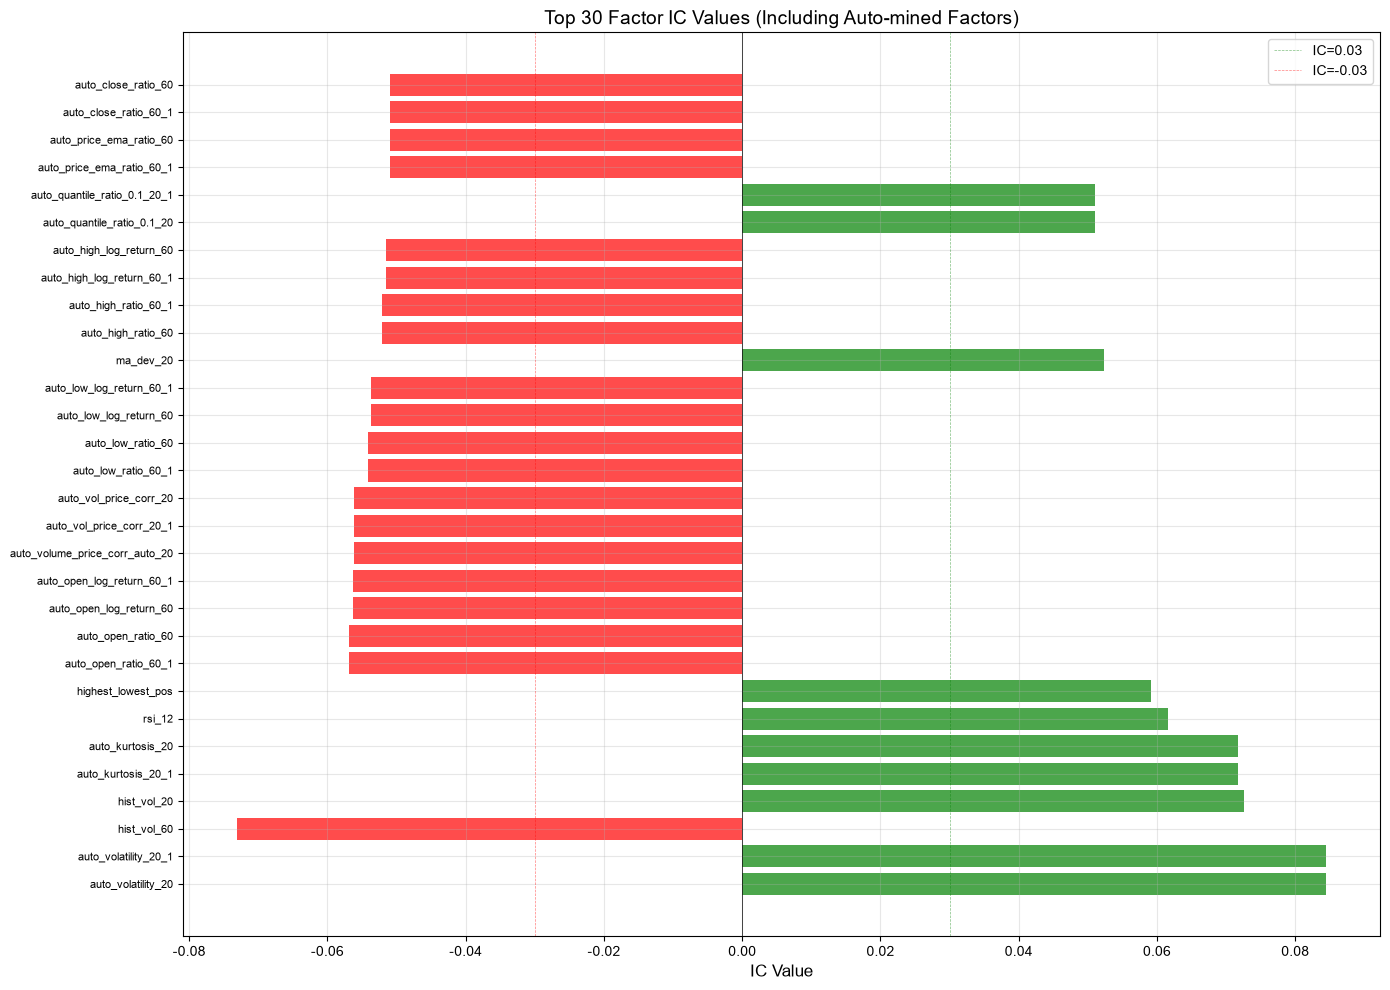

因子IC值图已保存到: extract-output/factor_ic_values_top30.png


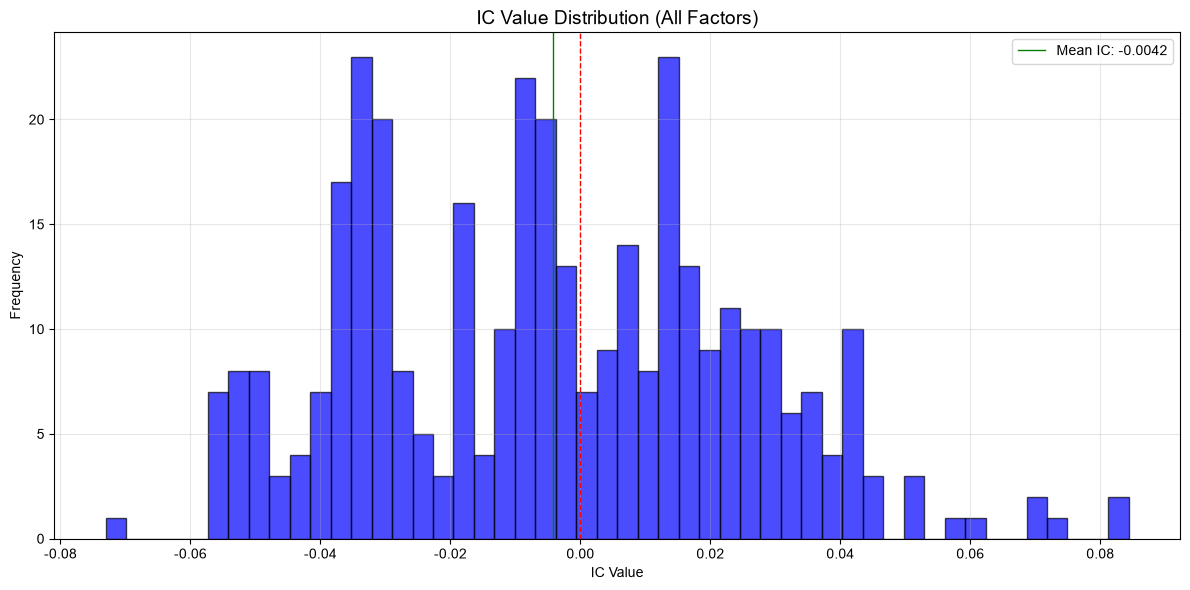

IC分布图已保存到: extract-output/ic_distribution_all_factors.png

IC统计:
  IC > 0.03: 40 个因子
  IC < -0.03: 94 个因子
  IC均值: -0.0042
  IC标准差: 0.0294


In [16]:
# ==================== 4. 计算未来5日收益 ====================
def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

print("\n计算未来5日收益...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("✅ 未来5日收益计算完成")

# ==================== 5. IC/IR分析 ====================
print("\n" + "="*80)
print("5. IC/IR分析")
print("="*80)

# 获取所有预处理后的因子列（包括自动挖掘的）
# 方法1：直接查找所有以 '_processed' 结尾的列
factor_cols_processed = [col for col in df.columns if col.endswith('_processed')]

# 方法2：或者从 all_factor_columns 构建
# factor_cols_processed = [f'{col}_processed' for col in all_factor_columns if f'{col}_processed' in df.columns]

print(f"待检验因子数量: {len(factor_cols_processed)}")
print(f"因子列名示例 (前10个): {factor_cols_processed[:10]}")

# 检查是否有缺失值
print("\n检查因子数据质量...")
for col in factor_cols_processed[:5]:
    nan_count = df[col].isna().sum()
    print(f"  {col}: NaN={nan_count}")

ic_results = []
print("\n计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    
    # 计算Spearman相关系数
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        try:
            ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
            if not np.isnan(ic):
                # 计算IC的p值
                p_value = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[1]
                ic_results.append({
                    'factor': col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'p_value': p_value,
                    'n_obs': len(valid_data)
                })
        except Exception as e:
            print(f"  计算 {col} IC时出错: {e}")
            continue

if len(ic_results) > 0:
    ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
    print("\n📊 因子IC值排名 (Top 30):")
    print(ic_df.head(30))
    
    # 保存完整IC结果到CSV
    ic_df.to_csv(os.path.join(output_dir, 'factor_ic_analysis_full.csv'), index=False)
    print(f"完整IC分析结果已保存到: {output_dir}/factor_ic_analysis_full.csv")
    
    # 保存Top 20 IC结果
    ic_df.head(20).to_csv(os.path.join(output_dir, 'factor_ic_analysis_top20.csv'), index=False)
    print(f"Top 20 IC分析结果已保存到: {output_dir}/factor_ic_analysis_top20.csv")
    
    # 绘制IC值分布 - Top 30
    fig, ax = plt.subplots(figsize=(14, 10))
    top_ic = ic_df.head(30)
    colors = ['green' if x > 0 else 'red' for x in top_ic['ic']]
    
    # 简化因子名称显示
    factor_names = [f.replace('_processed', '')[:40] for f in top_ic['factor']]
    
    bars = ax.barh(range(len(top_ic)), top_ic['ic'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_ic)))
    ax.set_yticklabels(factor_names, fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0.03, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='IC=0.03')
    ax.axvline(x=-0.03, color='red', linestyle='--', linewidth=0.5, alpha=0.5, label='IC=-0.03')
    ax.set_xlabel('IC Value', fontsize=12)
    ax.set_title('Top 30 Factor IC Values (Including Auto-mined Factors)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_ic_values_top30.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子IC值图已保存到: {output_dir}/factor_ic_values_top30.png")
    
    # 绘制IC值分布直方图
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(ic_df['ic'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.axvline(x=ic_df['ic'].mean(), color='green', linestyle='-', linewidth=1, label=f'Mean IC: {ic_df["ic"].mean():.4f}')
    ax.set_xlabel('IC Value')
    ax.set_ylabel('Frequency')
    ax.set_title('IC Value Distribution (All Factors)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'ic_distribution_all_factors.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"IC分布图已保存到: {output_dir}/ic_distribution_all_factors.png")
    
    # 统计IC>0.03的因子数量
    positive_ic_count = len(ic_df[ic_df['ic'] > 0.03])
    negative_ic_count = len(ic_df[ic_df['ic'] < -0.03])
    print(f"\nIC统计:")
    print(f"  IC > 0.03: {positive_ic_count} 个因子")
    print(f"  IC < -0.03: {negative_ic_count} 个因子")
    print(f"  IC均值: {ic_df['ic'].mean():.4f}")
    print(f"  IC标准差: {ic_df['ic'].std():.4f}")
    
else:
    print("❌ 没有有效的IC计算结果")
    ic_df = pd.DataFrame()


6. 分组单调性测试
测试因子单调性...
  处理进度: 0/50
  处理进度: 10/50
  处理进度: 20/50
  处理进度: 30/50
  处理进度: 40/50

📊 因子单调性测试结果 (Top 20):
                                    factor  monotonicity  is_monotonic  \
4             auto_kurtosis_20_1_processed           1.0          True   
5               auto_kurtosis_20_processed           1.0          True   
6                         rsi_12_processed           1.0          True   
48       auto_amount_ma_ratio_20_processed           1.0          True   
49     auto_amount_ma_ratio_20_1_processed           1.0          True   
19                     ma_dev_20_processed           1.0          True   
25  auto_quantile_ratio_0.1_20_1_processed           0.9          True   
7             highest_lowest_pos_processed           0.9          True   
47       auto_amount_ma_ratio_30_processed           0.9          True   
46     auto_amount_ma_ratio_30_1_processed           0.9          True   
24    auto_quantile_ratio_0.1_20_processed           0.9          True 

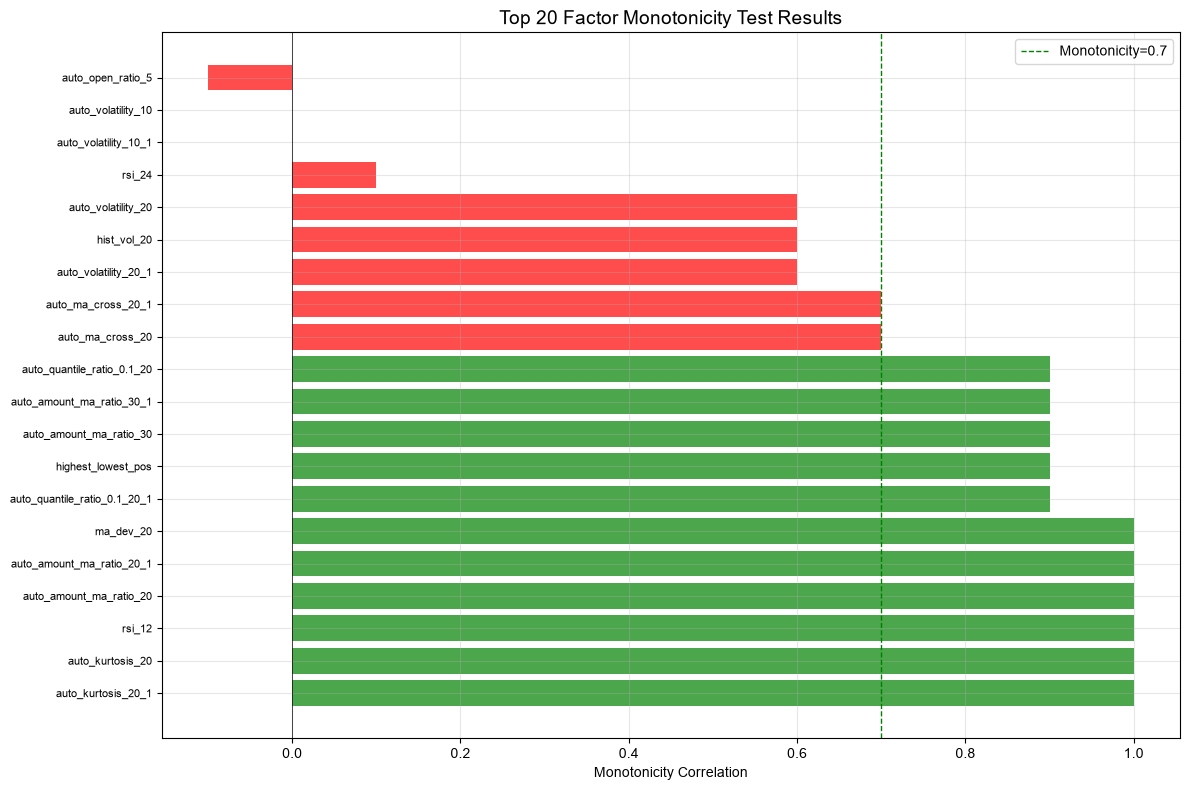

因子单调性图已保存到: extract-output/factor_monotonicity_top20.png

单调性统计:
  单调因子数量 (|monotonicity| > 0.7): 30
  单调性均值: -0.1520


In [17]:
# ==================== 6. 分组单调性测试 ====================
print("\n" + "="*80)
print("6. 分组单调性测试")
print("="*80)

def test_monotonicity(factor_col):
    """测试因子分组的单调性"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < 50:
        return None
    
    try:
        # 分成5组
        valid_data['group'] = pd.qcut(valid_data[factor_col], q=5, labels=False, duplicates='drop')
        if len(valid_data['group'].unique()) < 3:
            return None
        group_returns = valid_data.groupby('group')['future_5d_return'].mean()
        
        # 检查是否单调（使用Spearman相关系数）
        if len(group_returns) >= 3:
            monotonic_corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
            return monotonic_corr
    except Exception as e:
        return None
    return None

monotonic_results = []
print("测试因子单调性...")
# 选择IC绝对值最高的前50个因子进行测试
test_factor_cols = ic_df.nlargest(50, 'ic_abs')['factor'].tolist() if len(ic_df) > 0 else factor_cols_processed[:50]

for idx, col in enumerate(test_factor_cols):
    if idx % 10 == 0:
        print(f"  处理进度: {idx}/{len(test_factor_cols)}")
    mono_corr = test_monotonicity(col)
    if mono_corr is not None and not np.isnan(mono_corr):
        # 获取对应的IC值
        ic_value = ic_df[ic_df['factor'] == col]['ic'].values[0] if len(ic_df) > 0 else np.nan
        monotonic_results.append({
            'factor': col,
            'monotonicity': mono_corr,
            'is_monotonic': abs(mono_corr) > 0.7,
            'ic': ic_value
        })

if len(monotonic_results) > 0:
    monotonic_df = pd.DataFrame(monotonic_results).sort_values('monotonicity', ascending=False)
    print("\n📊 因子单调性测试结果 (Top 20):")
    print(monotonic_df.head(20))
    
    # 保存单调性结果到CSV
    monotonic_df.to_csv(os.path.join(output_dir, 'factor_monotonicity_full.csv'), index=False)
    print(f"完整单调性测试结果已保存到: {output_dir}/factor_monotonicity_full.csv")
    
    # 绘制单调性结果
    fig, ax = plt.subplots(figsize=(12, 8))
    top_mono = monotonic_df.head(20)
    colors = ['green' if x else 'red' for x in top_mono['is_monotonic']]
    factor_names = [f.replace('_processed', '')[:40] for f in top_mono['factor']]
    
    bars = ax.barh(range(len(top_mono)), top_mono['monotonicity'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_mono)))
    ax.set_yticklabels(factor_names, fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0.7, color='green', linestyle='--', linewidth=1, label='Monotonicity=0.7')
    ax.set_xlabel('Monotonicity Correlation')
    ax.set_title('Top 20 Factor Monotonicity Test Results', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_monotonicity_top20.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子单调性图已保存到: {output_dir}/factor_monotonicity_top20.png")
    
    # 统计单调因子
    monotonic_count = len(monotonic_df[monotonic_df['is_monotonic']])
    print(f"\n单调性统计:")
    print(f"  单调因子数量 (|monotonicity| > 0.7): {monotonic_count}")
    print(f"  单调性均值: {monotonic_df['monotonicity'].mean():.4f}")
    
else:
    print("❌ 没有有效的单调性测试结果")


7. 因子综合筛选（IC + IR + 单调性 + 相关性）
计算因子综合指标...
  处理进度: 0/200
  处理进度: 20/200
  处理进度: 40/200
  处理进度: 60/200
  处理进度: 80/200
  处理进度: 100/200
  处理进度: 120/200
  处理进度: 140/200
  处理进度: 160/200
  处理进度: 180/200
覆盖率过滤后剩余: 200 个因子
IC绝对值过滤后剩余: 188 个因子

📊 因子综合评分排名 (Top 30):
                                  factor        ic        ir  monotonicity  ic_win_rate  composite_score
5             auto_kurtosis_20_processed  0.071792  0.090900           1.0       0.4875         0.831081
4           auto_kurtosis_20_1_processed  0.071792  0.090900           1.0       0.4875         0.831081
2                  hist_vol_60_processed -0.073062  0.017730          -0.9       0.6500         0.830226
0           auto_volatility_20_processed  0.084388  0.205274           0.6       0.5000         0.818452
1         auto_volatility_20_1_processed  0.084388  0.205274           0.6       0.5000         0.818452
3                  hist_vol_20_processed  0.072586  0.180633           0.6       0.7625         0.807992
30     

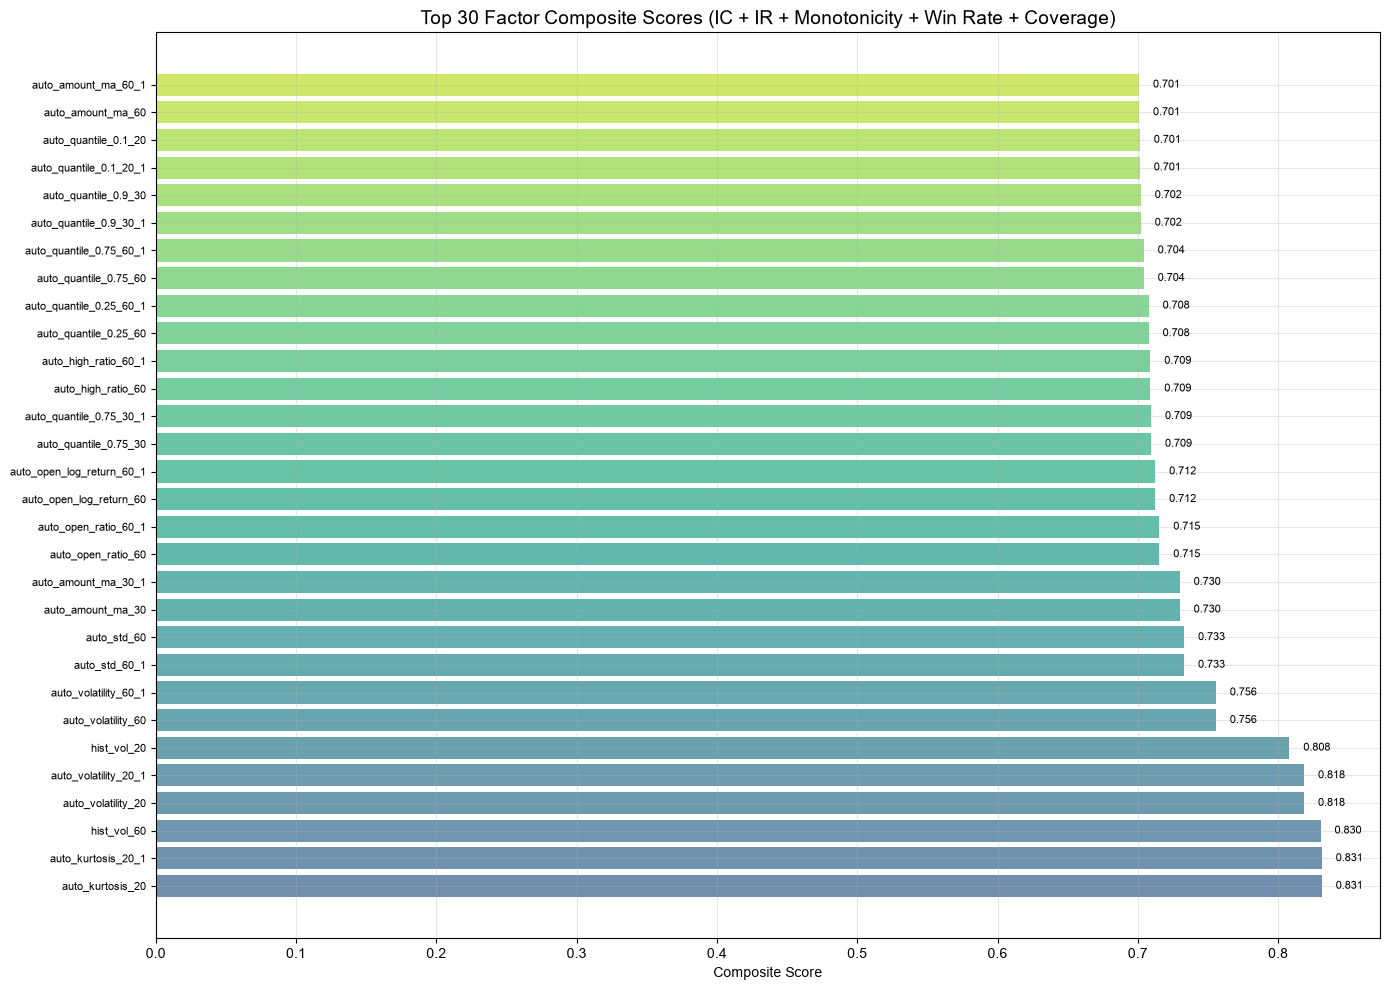

因子综合评分图已保存到: extract-output/factor_composite_scores.png

8. 选择Top因子并剔除相关性冗余

从综合评分前 50 个因子中选择，目标保留 25 个因子
相关性矩阵已保存到: extract-output/factor_correlation_top.csv


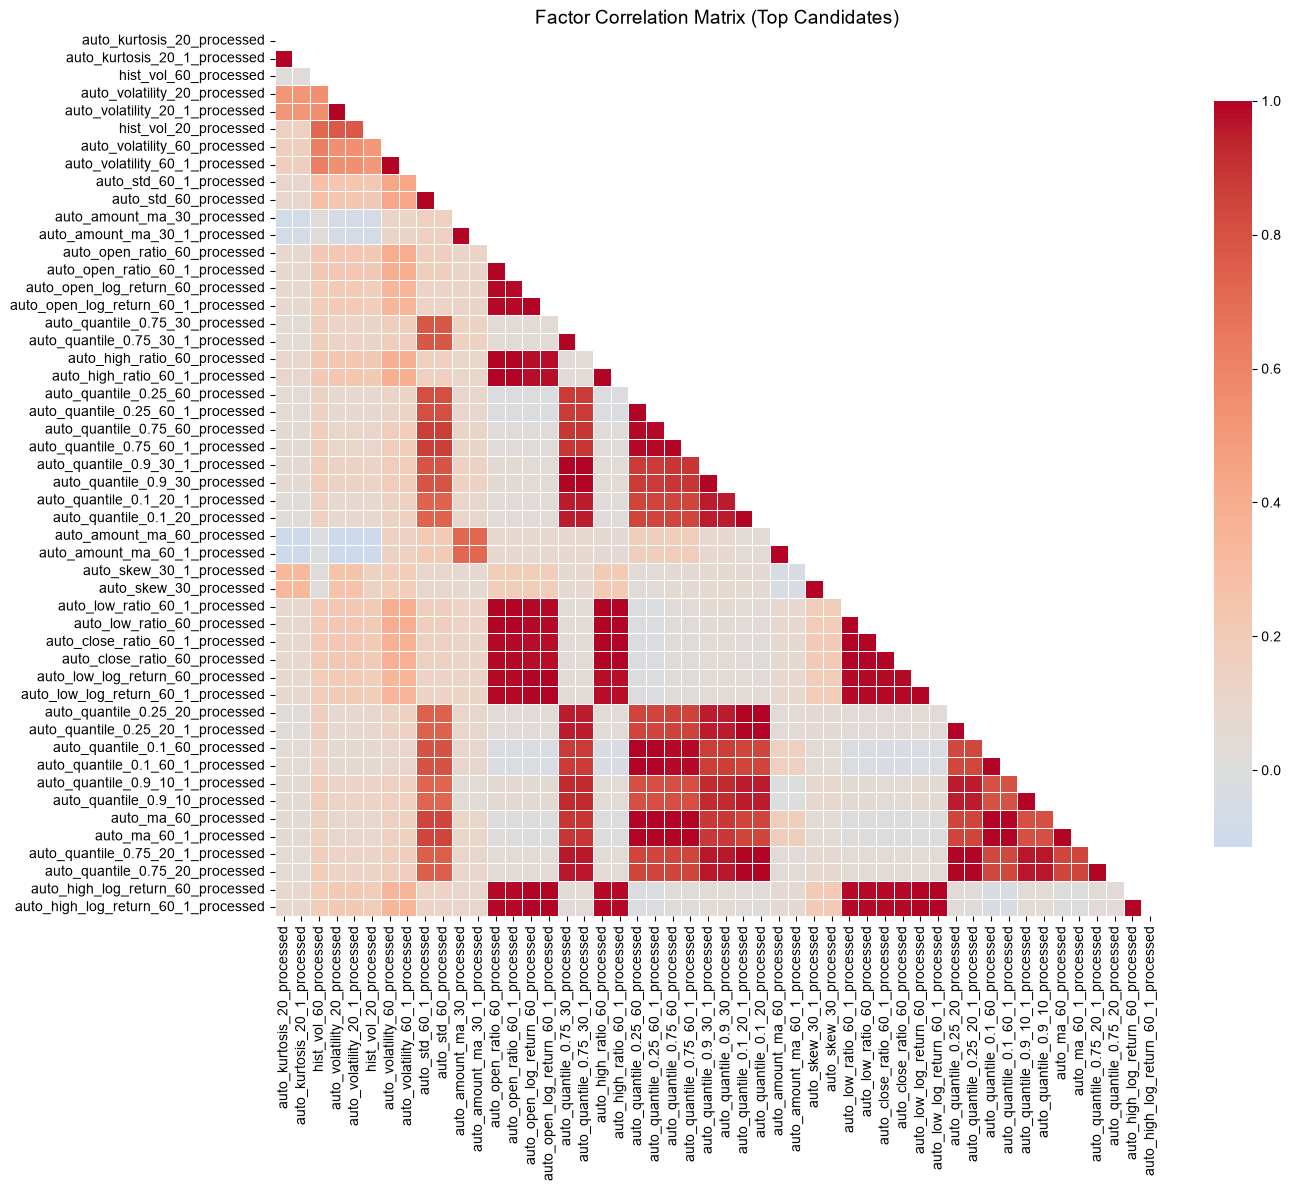

相关性热力图已保存到: extract-output/factor_correlation_top.png

从 50 个候选因子中，通过聚类选择了 25 个代表性因子

仍有 64 对高相关因子 (>0.8)，进行微调...
剔除 14 个因子，当前共 11 个因子
补充后共 20 个因子

🎯 最终选择的因子: 20个
最终因子列表:
   1. auto_kurtosis_20                                   | IC: 0.0718 | IR: 0.0909 | Mono: 1.0000 | Score: 0.8311
   2. hist_vol_60                                        | IC: -0.0731 | IR: 0.0177 | Mono: -0.9000 | Score: 0.8302
   3. auto_volatility_20                                 | IC: 0.0844 | IR: 0.2053 | Mono: 0.6000 | Score: 0.8185
   4. hist_vol_20                                        | IC: 0.0726 | IR: 0.1806 | Mono: 0.6000 | Score: 0.8080
   5. auto_volatility_60                                 | IC: -0.0509 | IR: 0.1080 | Mono: -0.9000 | Score: 0.7556
   6. auto_std_60_1                                      | IC: -0.0398 | IR: 0.2308 | Mono: -0.9000 | Score: 0.7329
   7. auto_amount_ma_30                                  | IC: -0.0349 | IR: 0.3455 | Mono: -0.9000 | Score: 0.7298
   8. auto_open_ratio_6

In [20]:
# ==================== 7. 因子综合筛选（多维度评分） ====================
print("\n" + "="*80)
print("7. 因子综合筛选（IC + IR + 单调性 + 相关性）")
print("="*80)

def calculate_ir(factor_col, window=20):
    """计算因子的IR"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < window:
        return 0
    
    ic_series = []
    for i in range(window, len(valid_data)):
        sub_data = valid_data.iloc[i-window:i]
        if len(sub_data) > 10:
            ic = stats.spearmanr(sub_data[factor_col], sub_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_series.append(ic)
    
    if len(ic_series) > 0:
        ir = np.mean(ic_series) / (np.std(ic_series) + 1e-6)
        return ir
    return 0

def test_monotonicity_single(factor_col):
    """测试单个因子的单调性"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < 50:
        return None
    
    try:
        valid_data['group'] = pd.qcut(valid_data[factor_col], q=5, labels=False, duplicates='drop')
        if len(valid_data['group'].unique()) < 3:
            return None
        group_returns = valid_data.groupby('group')['future_5d_return'].mean()
        if len(group_returns) >= 3:
            monotonic_corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
            return monotonic_corr
    except:
        return None
    return None

print("计算因子综合指标...")
factor_metrics = []

# 对IC绝对值排名前200的因子进行综合评估
candidate_factors = ic_df.nlargest(200, 'ic_abs')['factor'].tolist() if len(ic_df) > 0 else factor_cols_processed[:200]

for idx, col in enumerate(candidate_factors):
    if idx % 20 == 0:
        print(f"  处理进度: {idx}/{len(candidate_factors)}")
    
    # 计算IC
    ic_info = ic_df[ic_df['factor'] == col]
    ic_value = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
    ic_abs = abs(ic_value)
    
    # 计算IR
    ir = calculate_ir(col)
    
    # 计算单调性
    mono = test_monotonicity_single(col)
    
    # 计算因子覆盖率
    coverage = df[col].notna().mean()
    
    # 计算IC胜率（IC为正的比例）
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        ic_positive = 0
        total_windows = 0
        for i in range(20, min(len(valid_data), 100)):
            sub_data = valid_data.iloc[i-20:i]
            if len(sub_data) > 10:
                ic = stats.spearmanr(sub_data[col], sub_data['future_5d_return'])[0]
                if not np.isnan(ic):
                    if ic > 0:
                        ic_positive += 1
                    total_windows += 1
        ic_win_rate = ic_positive / (total_windows + 1e-6) if total_windows > 0 else 0.5
    else:
        ic_win_rate = 0.5
    
    factor_metrics.append({
        'factor': col,
        'ic': ic_value,
        'ic_abs': ic_abs,
        'ir': ir,
        'monotonicity': mono if mono is not None else 0,
        'ic_win_rate': ic_win_rate,
        'coverage': coverage,
        'n_obs': ic_info['n_obs'].values[0] if len(ic_info) > 0 and 'n_obs' in ic_info.columns else 0
    })

# 转换为DataFrame
factor_metrics_df = pd.DataFrame(factor_metrics)

# 过滤掉覆盖率低于40%的因子
factor_metrics_df = factor_metrics_df[factor_metrics_df['coverage'] > 0.4]
print(f"覆盖率过滤后剩余: {len(factor_metrics_df)} 个因子")

# 过滤掉IC绝对值太低的因子 (< 0.02)
factor_metrics_df = factor_metrics_df[factor_metrics_df['ic_abs'] > 0.02]
print(f"IC绝对值过滤后剩余: {len(factor_metrics_df)} 个因子")

# 计算综合得分（归一化后加权）
factor_metrics_df['ic_score'] = (factor_metrics_df['ic_abs'] - factor_metrics_df['ic_abs'].min()) / (factor_metrics_df['ic_abs'].max() - factor_metrics_df['ic_abs'].min() + 1e-6)
factor_metrics_df['ir_score'] = (factor_metrics_df['ir'] - factor_metrics_df['ir'].min()) / (factor_metrics_df['ir'].max() - factor_metrics_df['ir'].min() + 1e-6)
factor_metrics_df['mono_score'] = (factor_metrics_df['monotonicity'].abs() - factor_metrics_df['monotonicity'].abs().min()) / (factor_metrics_df['monotonicity'].abs().max() - factor_metrics_df['monotonicity'].abs().min() + 1e-6)
factor_metrics_df['win_rate_score'] = factor_metrics_df['ic_win_rate']
factor_metrics_df['coverage_score'] = factor_metrics_df['coverage']

# 综合得分
factor_metrics_df['composite_score'] = (factor_metrics_df['ic_score'] * 0.25 + 
                                        factor_metrics_df['ir_score'] * 0.25 + 
                                        factor_metrics_df['mono_score'] * 0.20 + 
                                        factor_metrics_df['win_rate_score'] * 0.15 + 
                                        factor_metrics_df['coverage_score'] * 0.15)

# 按综合得分排序
factor_metrics_df = factor_metrics_df.sort_values('composite_score', ascending=False)

print(f"\n📊 因子综合评分排名 (Top 30):")
display_cols = ['factor', 'ic', 'ir', 'monotonicity', 'ic_win_rate', 'composite_score']
print(factor_metrics_df[display_cols].head(30).to_string())

# 保存综合评分结果
factor_metrics_df.to_csv(os.path.join(output_dir, 'factor_composite_scores.csv'), index=False)
print(f"因子综合评分已保存到: {output_dir}/factor_composite_scores.csv")

# 绘制综合评分图
fig, ax = plt.subplots(figsize=(14, 10))
top_factors = factor_metrics_df.head(30)
factor_names = [f.replace('_processed', '')[:40] for f in top_factors['factor']]

bars = ax.barh(range(len(top_factors)), top_factors['composite_score'], alpha=0.7, 
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_factors))))
ax.set_yticks(range(len(top_factors)))
ax.set_yticklabels(factor_names, fontsize=8)
ax.set_xlabel('Composite Score')
ax.set_title('Top 30 Factor Composite Scores (IC + IR + Monotonicity + Win Rate + Coverage)', fontsize=14)
ax.grid(True, alpha=0.3)

# 添加数值标签
for i, (bar, score) in enumerate(zip(bars, top_factors['composite_score'])):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'factor_composite_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"因子综合评分图已保存到: {output_dir}/factor_composite_scores.png")

# ==================== 8. 选择Top因子并剔除相关性冗余 ====================
print("\n" + "="*80)
print("8. 选择Top因子并剔除相关性冗余")
print("="*80)

# 目标保留因子数量
TARGET_FACTORS = 25

# 选择综合得分最高的前N个因子（2倍目标，为后续筛选留空间）
selected_top = factor_metrics_df.head(TARGET_FACTORS * 2)['factor'].tolist()
print(f"\n从综合评分前 {len(selected_top)} 个因子中选择，目标保留 {TARGET_FACTORS} 个因子")

if len(selected_top) > 1:
    # 提取因子数据
    factor_data_for_corr = df[selected_top].copy()
    
    # 计算相关性矩阵
    factor_corr = factor_data_for_corr.corr()
    
    # 保存相关性矩阵
    factor_corr.to_csv(os.path.join(output_dir, 'factor_correlation_top.csv'))
    print(f"相关性矩阵已保存到: {output_dir}/factor_correlation_top.csv")
    
    # 绘制相关性热力图
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(factor_corr, dtype=bool))
    sns.heatmap(factor_corr, mask=mask, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Factor Correlation Matrix (Top Candidates)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_correlation_top.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"相关性热力图已保存到: {output_dir}/factor_correlation_top.png")
    
    # 使用层次聚类选择代表性因子
    from scipy.cluster.hierarchy import linkage, fcluster
    
    # 计算距离矩阵 (1 - 相关系数)
    distance_matrix = 1 - factor_corr.abs()
    
    # 层次聚类
    linkage_matrix = linkage(distance_matrix, method='average')
    
    # 设定聚类数量为目标因子数
    n_clusters = min(TARGET_FACTORS, len(selected_top) // 2)
    clusters = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    
    # 在每个聚类中选择综合得分最高的因子
    selected_factors_final = []
    cluster_to_factors = {}
    
    for factor, cluster_id in zip(selected_top, clusters):
        if cluster_id not in cluster_to_factors:
            cluster_to_factors[cluster_id] = []
        score = factor_metrics_df[factor_metrics_df['factor'] == factor]['composite_score'].values
        if len(score) > 0:
            cluster_to_factors[cluster_id].append((factor, score[0]))
    
    # 从每个聚类中选择得分最高的因子
    for cluster_id, factors in cluster_to_factors.items():
        factors_sorted = sorted(factors, key=lambda x: x[1], reverse=True)
        selected_factors_final.append(factors_sorted[0][0])
    
    print(f"\n从 {len(selected_top)} 个候选因子中，通过聚类选择了 {len(selected_factors_final)} 个代表性因子")
    
    # 如果选择的因子数量不够目标，从剩余候选中补充
    if len(selected_factors_final) < TARGET_FACTORS:
        remaining = [f for f in selected_top if f not in selected_factors_final]
        remaining_sorted = factor_metrics_df[factor_metrics_df['factor'].isin(remaining)].sort_values('composite_score', ascending=False)
        additional = remaining_sorted.head(TARGET_FACTORS - len(selected_factors_final))['factor'].tolist()
        selected_factors_final.extend(additional)
        print(f"补充了 {len(additional)} 个因子，当前共 {len(selected_factors_final)} 个因子")
    
    # 如果因子太多，保留综合得分最高的
    if len(selected_factors_final) > TARGET_FACTORS + 5:
        final_scores = []
        for f in selected_factors_final:
            score = factor_metrics_df[factor_metrics_df['factor'] == f]['composite_score'].values
            final_scores.append(score[0] if len(score) > 0 else 0)
        sorted_indices = np.argsort(final_scores)[::-1]
        selected_factors_final = [selected_factors_final[i] for i in sorted_indices[:TARGET_FACTORS]]
        print(f"截断到 {len(selected_factors_final)} 个因子")
    
    # 最终检查：如果还有高相关的因子对 (>0.8)，进行微调
    if len(selected_factors_final) > 1:
        final_data = df[selected_factors_final].copy()
        final_corr = final_data.corr()
        
        high_corr_pairs_final = []
        for i in range(len(selected_factors_final)):
            for j in range(i+1, len(selected_factors_final)):
                if abs(final_corr.iloc[i, j]) > 0.8:
                    high_corr_pairs_final.append((selected_factors_final[i], selected_factors_final[j], final_corr.iloc[i, j]))
        
        if high_corr_pairs_final:
            print(f"\n仍有 {len(high_corr_pairs_final)} 对高相关因子 (>0.8)，进行微调...")
            to_remove_final = set()
            for f1, f2, corr in high_corr_pairs_final:
                score1 = factor_metrics_df[factor_metrics_df['factor'] == f1]['composite_score'].values
                score2 = factor_metrics_df[factor_metrics_df['factor'] == f2]['composite_score'].values
                if len(score1) > 0 and len(score2) > 0:
                    if score1[0] < score2[0]:
                        to_remove_final.add(f1)
                    else:
                        to_remove_final.add(f2)
            
            selected_factors_final = [f for f in selected_factors_final if f not in to_remove_final]
            print(f"剔除 {len(to_remove_final)} 个因子，当前共 {len(selected_factors_final)} 个因子")
            
            # 如果剔除后太少，补充一些
            if len(selected_factors_final) < 15:
                remaining_all = [f for f in factor_metrics_df['factor'].tolist() if f not in selected_factors_final]
                additional = factor_metrics_df[factor_metrics_df['factor'].isin(remaining_all)].head(20 - len(selected_factors_final))['factor'].tolist()
                selected_factors_final.extend(additional)
                print(f"补充后共 {len(selected_factors_final)} 个因子")
    
    final_factors = selected_factors_final
    
else:
    print("因子数量不足，使用全部候选因子")
    final_factors = selected_top

# 确保至少有15个因子
if len(final_factors) < 15:
    print(f"\n当前因子数量 {len(final_factors)} 少于15，从候选中补充...")
    remaining_all = [f for f in factor_metrics_df['factor'].tolist() if f not in final_factors]
    additional = factor_metrics_df[factor_metrics_df['factor'].isin(remaining_all)].head(20 - len(final_factors))['factor'].tolist()
    final_factors.extend(additional)
    print(f"补充后共 {len(final_factors)} 个因子")

print(f"\n🎯 最终选择的因子: {len(final_factors)}个")
print(f"最终因子列表:")
for i, f in enumerate(final_factors, 1):
    info = factor_metrics_df[factor_metrics_df['factor'] == f]
    if len(info) > 0:
        ic_val = info['ic'].values[0]
        ir_val = info['ir'].values[0]
        mono_val = info['monotonicity'].values[0]
        score_val = info['composite_score'].values[0]
        print(f"  {i:2d}. {f.replace('_processed', '')[:50]:<50} | IC: {ic_val:.4f} | IR: {ir_val:.4f} | Mono: {mono_val:.4f} | Score: {score_val:.4f}")

# 保存最终因子列表（包含详细信息）
final_factors_detail = []
for f in final_factors:
    info = factor_metrics_df[factor_metrics_df['factor'] == f]
    if len(info) > 0:
        final_factors_detail.append({
            'factor_name': f,
            'ic': info['ic'].values[0],
            'ic_abs': info['ic_abs'].values[0],
            'ir': info['ir'].values[0],
            'monotonicity': info['monotonicity'].values[0],
            'ic_win_rate': info['ic_win_rate'].values[0],
            'composite_score': info['composite_score'].values[0],
            'coverage': info['coverage'].values[0],
            'rank': len(final_factors_detail) + 1
        })

final_factors_df = pd.DataFrame(final_factors_detail)
final_factors_df.to_csv(os.path.join(output_dir, 'final_selected_factors_with_metrics.csv'), index=False)
print(f"\n最终因子详细信息已保存到: {output_dir}/final_selected_factors_with_metrics.csv")

# 保存简单列表
pd.DataFrame({
    'factor_name': final_factors,
    'rank': range(1, len(final_factors) + 1),
    'is_selected': 1
}).to_csv(os.path.join(output_dir, 'final_selected_factors_list.csv'), index=False)
print(f"最终因子列表已保存到: {output_dir}/final_selected_factors_list.csv")

print(f"\n✅ 最终筛选完成，保留 {len(final_factors)} 个因子")

# ==================== 9. 保存筛选后的因子数据 ====================
print("\n" + "="*80)
print("9. 保存筛选后的因子数据")
print("="*80)

# 提取筛选后的因子值（原始值，非预处理值）
original_factor_names = [f.replace('_processed', '') for f in final_factors]
original_factor_names = [f for f in original_factor_names if f in df.columns]

# 如果原始因子列不存在，使用预处理后的列
if len(original_factor_names) == 0:
    print("原始因子列不存在，使用预处理后的因子列")
    original_factor_names = final_factors

print(f"提取 {len(original_factor_names)} 个因子的数据...")

# 构建输出数据
output_df = pd.DataFrame()
output_df['ts_code'] = df['ts_code']
output_df['trade_date'] = df['trade_date']

# 添加基础价格数据
base_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg']
for col in base_cols:
    if col in df.columns:
        output_df[col] = df[col]

# 添加基础衍生指标
derived_cols = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
for col in derived_cols:
    if col in df.columns:
        output_df[col] = df[col]

# 添加因子数据
for factor in original_factor_names:
    if factor in df.columns:
        output_df[factor] = df[factor]
    else:
        processed_factor = f'{factor}_processed'
        if processed_factor in df.columns:
            output_df[factor] = df[processed_factor]
        else:
            print(f"警告: 因子 {factor} 不存在于数据中")

# 添加未来5日收益
if 'future_5d_return' in df.columns:
    output_df['future_5d_return'] = df['future_5d_return']

# 添加月份标识
output_df['year_month'] = df['trade_date'].dt.to_period('M')

# ==================== 保存到 ../extracted_data/ 目录 ====================
extracted_data_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'extracted_data')
if not os.path.exists(extracted_data_dir):
    os.makedirs(extracted_data_dir)
    print(f"创建目录: {extracted_data_dir}")

output_file = os.path.join(extracted_data_dir, 'selected_factors_with_data1.csv')
output_df.to_csv(output_file, index=False)
print(f"✅ 筛选后的因子数据已保存到: {output_file}")
print(f"   数据形状: {output_df.shape}")
print(f"   包含因子数量: {len(original_factor_names)}")
print(f"   时间范围: {output_df['trade_date'].min()} 至 {output_df['trade_date'].max()}")

# 同时也在output_dir保存一份备份
backup_file = os.path.join(output_dir, 'selected_factors_with_data_backup.csv')
output_df.to_csv(backup_file, index=False)
print(f"✅ 备份数据已保存到: {backup_file}")

# ==================== 10. 保存因子统计信息 ====================
print("\n" + "="*80)
print("10. 保存因子统计信息")
print("="*80)

factor_stats = []
for factor in original_factor_names:
    if factor in output_df.columns:
        factor_stats.append({
            'factor_name': factor,
            'mean': output_df[factor].mean(),
            'std': output_df[factor].std(),
            'min': output_df[factor].min(),
            'max': output_df[factor].max(),
            'skew': output_df[factor].skew(),
            'kurtosis': output_df[factor].kurt(),
            'coverage': output_df[factor].notna().mean()
        })

if factor_stats:
    factor_stats_df = pd.DataFrame(factor_stats)
    factor_stats_df.to_csv(os.path.join(output_dir, 'selected_factors_statistics.csv'), index=False)
    print(f"因子统计信息已保存到: {output_dir}/selected_factors_statistics.csv")

# ==================== 11. 最终总结报告 ====================
print("\n" + "="*80)
print("11. 因子筛选总结报告")
print("="*80)

# 统计因子来源
auto_count = len([f for f in final_factors if f.startswith('auto_') or f.startswith('auto')])
base_count = len(final_factors) - auto_count

print(f"""
📊 因子筛选完整总结
================================================================
原始数据:
- 股票数量: {df['ts_code'].nunique()} 只
- 数据时间范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}
- 总记录数: {len(df)} 条

因子数量统计:
- 基础技术因子: {len(base_factor_columns)} 个
- 自动挖掘因子: {len(auto_factor_columns)} 个
- 总因子数量: {len(all_factor_columns)} 个

筛选过程:
- 覆盖率过滤后: {len(factor_metrics_df)} 个
- 最终选择: {len(final_factors)} 个

最终因子构成:
- 基础技术因子: {base_count} 个
- 自动挖掘因子: {auto_count} 个

输出文件:
主数据文件:
- {extracted_data_dir}/selected_factors_with_data1.csv (包含所有筛选因子)

分析文件 (output目录):
- {output_dir}/factor_composite_scores.csv - 因子综合评分
- {output_dir}/final_selected_factors_with_metrics.csv - 最终因子详细信息
- {output_dir}/final_selected_factors_list.csv - 最终因子列表
- {output_dir}/selected_factors_statistics.csv - 因子统计信息
- {output_dir}/factor_correlation_top.csv - 相关性矩阵

可视化文件:
- {output_dir}/factor_composite_scores.png - 综合评分排名图
- {output_dir}/factor_correlation_top.png - 相关性热力图
- {output_dir}/factor_ic_values_top30.png - IC值排名图
- {output_dir}/factor_ir_values_top30.png - IR值排名图
================================================================
""")

# 验证保存的文件是否存在
if os.path.exists(output_file):
    file_size = os.path.getsize(output_file) / 1024
    print(f"✅ 验证: 数据文件已成功保存")
    print(f"   文件路径: {output_file}")
    print(f"   文件大小: {file_size:.2f} KB")
    
    # 读取验证
    verify_df = pd.read_csv(output_file)
    print(f"   验证读取形状: {verify_df.shape}")
    print(f"   列数: {len(verify_df.columns)}")
else:
    print(f"❌ 警告: 数据文件保存失败!")

print("\n" + "="*80)
print("✅ 因子挖掘、筛选和数据保存全部完成！")
print("="*80)

In [21]:
# 获取最终因子的原始列名
final_factor_original = [f.replace('_processed', '') for f in final_factors]
# 只保留存在于df中的因子
final_factor_original = [f for f in final_factor_original if f in df.columns]

print(f"用于加权计算的因子数量: {len(final_factor_original)}")

# 提取因子数据（原始值）
factor_data_raw = df[final_factor_original].copy()

# 处理缺失值和异常值
factor_data_raw = factor_data_raw.replace([np.inf, -np.inf], np.nan)
factor_data_raw = factor_data_raw.ffill().bfill().fillna(0)

# 获取每个因子的IC值和IR值（从factor_metrics_df中获取）
factor_weights_info = []
has_ir_info = False

for f in final_factor_original:
    # 查找对应的processed因子名
    processed_name = f'{f}_processed'
    
    # 从factor_metrics_df获取信息
    info = factor_metrics_df[factor_metrics_df['factor'] == processed_name]
    
    if len(info) > 0:
        ic_val = info['ic'].values[0]
        ir_val = info['ir'].values[0]
        if ir_val != 0:
            has_ir_info = True
    else:
        # 如果找不到，尝试从ic_df获取
        ic_info = ic_df[ic_df['factor'] == processed_name]
        ic_val = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
        ir_val = 0
    
    factor_weights_info.append({
        'factor': f,
        'ic': ic_val,
        'ir': ir_val,
        'ic_abs': abs(ic_val)
    })

factor_weights_df = pd.DataFrame(factor_weights_info)
print("\n因子权重信息:")
print(factor_weights_df)

# 12.1 确定加权方式
print("\n12.1 确定加权方式...")

# 检查是否有有效的IR信息
if has_ir_info:
    print("检测到IR信息，使用IR加权")
    use_ir_weighting = True
else:
    print("未检测到IR信息，使用IC加权")
    use_ir_weighting = False

# 12.2 计算权重
print("\n12.2 计算权重...")

if use_ir_weighting:
    # IR加权
    weights = factor_weights_df['ir'].values
    weight_type = 'IR'
    # 处理负值：如果IR为负，取绝对值
    weights = np.maximum(weights, 0)
else:
    # IC加权（使用IC绝对值）
    weights = factor_weights_df['ic_abs'].values
    weight_type = 'IC'
    # IC权重直接使用绝对值

# 检查权重是否全为0
if weights.sum() > 0:
    weights = weights / weights.sum()
else:
    # 如果所有权重都为0，使用等权
    weights = np.ones(len(factor_weights_df)) / len(factor_weights_df)
    print(f"{weight_type}权重全为0，使用等权替代")

# 创建权重字典
weight_dict = dict(zip(factor_weights_df['factor'], weights))

print(f"\n{weight_type}加权权重:")
for f, w in zip(factor_weights_df['factor'], weights):
    print(f"  {f}: {w:.4f}")

# 12.3 等权
print("\n12.3 等权计算...")
equal_weights = np.ones(len(factor_weights_df)) / len(factor_weights_df)
equal_weight_dict = dict(zip(factor_weights_df['factor'], equal_weights))

print("等权权重:")
for f, w in zip(factor_weights_df['factor'], equal_weights):
    print(f"  {f}: {w:.4f}")

# 保存权重信息
weights_df = pd.DataFrame({
    'factor': factor_weights_df['factor'],
    'ic': factor_weights_df['ic'],
    'ir': factor_weights_df['ir'],
    f'{weight_type}_weight': weights,
    'equal_weight': equal_weights,
    'weight_type': weight_type if use_ir_weighting else 'IC'
})
weights_df.to_csv(os.path.join(output_dir, 'factor_weights.csv'), index=False)
print(f"\n权重信息已保存到: {output_dir}/factor_weights.csv")

用于加权计算的因子数量: 20

因子权重信息:
                       factor        ic        ir    ic_abs
0            auto_kurtosis_20  0.071792  0.090900  0.071792
1                 hist_vol_60 -0.073062  0.017730  0.073062
2          auto_volatility_20  0.084388  0.205274  0.084388
3                 hist_vol_20  0.072586  0.180633  0.072586
4          auto_volatility_60 -0.050866  0.107987  0.050866
5               auto_std_60_1 -0.039786  0.230801  0.039786
6           auto_amount_ma_30 -0.034919  0.345466  0.034919
7          auto_open_ratio_60 -0.056831 -0.374962  0.056831
8       auto_quantile_0.75_30 -0.032921  0.255205  0.032921
9           auto_amount_ma_60 -0.025766  0.395240  0.025766
10             auto_skew_30_1  0.033589  0.214689  0.033589
11         auto_kurtosis_20_1  0.071792  0.090900  0.071792
12       auto_volatility_20_1  0.084388  0.205274  0.084388
13       auto_volatility_60_1 -0.050866  0.107987  0.050866
14                auto_std_60 -0.039786  0.230801  0.039786
15        auto_


12.4 计算综合因子得分...

综合因子得分统计 (IR_Weighted):
count    2.397900e+04
mean    -3.792880e-17
std      5.615711e-01
min     -8.015913e-01
25%     -3.668180e-01
50%     -1.527905e-01
75%      1.850253e-01
max      4.010410e+00
Name: composite_score_weighted, dtype: float64

综合因子得分统计 (Equal Weighted):
count    2.397900e+04
mean    -2.844660e-17
std      5.494503e-01
min     -8.917920e-01
25%     -3.647171e-01
50%     -1.206370e-01
75%      2.071868e-01
max      3.954512e+00
Name: composite_score_equal, dtype: float64


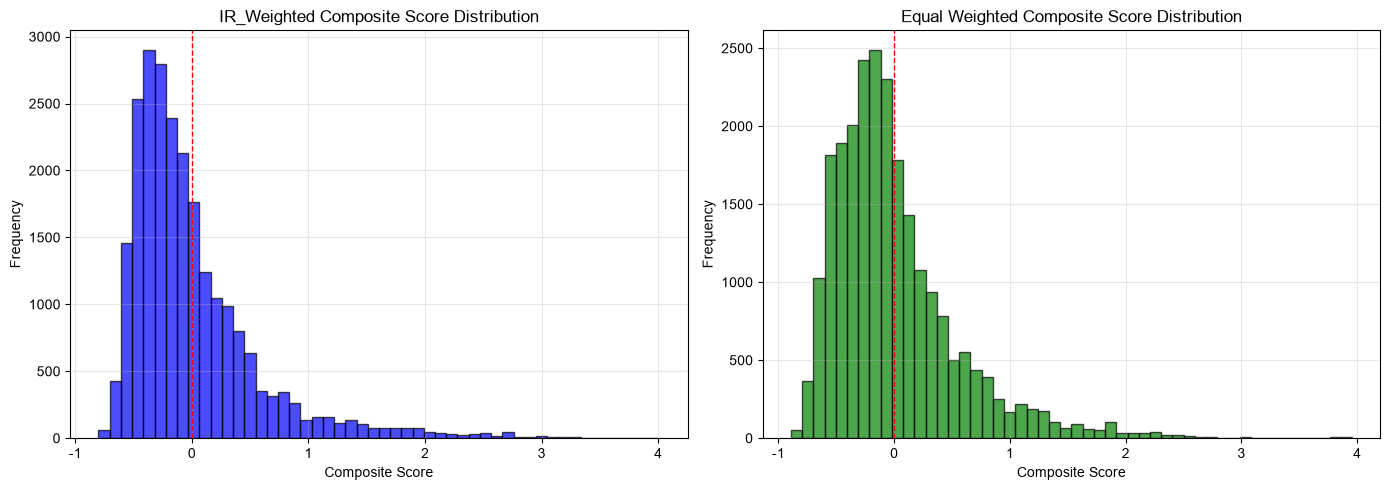

综合得分分布图已保存到: extract-output/composite_score_distribution.png


In [22]:
print("\n12.4 计算综合因子得分...")

def calculate_composite_score(factor_data, weights_dict):
    """计算综合因子得分"""
    score = np.zeros(len(factor_data))
    for factor, weight in weights_dict.items():
        if factor in factor_data.columns:
            # 对每个因子进行Z-score标准化后再加权
            factor_values = factor_data[factor].values
            if factor_values.std() > 0:
                factor_std = (factor_values - factor_values.mean()) / (factor_values.std() + 1e-6)
                score += factor_std * weight
            else:
                score += factor_values * weight
    return score

# 计算加权综合得分（使用IR或IC）
df['composite_score_weighted'] = calculate_composite_score(factor_data_raw, weight_dict)
strategy_name = f'{weight_type}_Weighted'

# 计算等权综合得分
df['composite_score_equal'] = calculate_composite_score(factor_data_raw, equal_weight_dict)

print(f"\n综合因子得分统计 ({strategy_name}):")
print(df['composite_score_weighted'].describe())
print(f"\n综合因子得分统计 (Equal Weighted):")
print(df['composite_score_equal'].describe())

# 绘制综合得分分布对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['composite_score_weighted'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Composite Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'{strategy_name} Composite Score Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['composite_score_equal'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Composite Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Equal Weighted Composite Score Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'composite_score_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"综合得分分布图已保存到: {output_dir}/composite_score_distribution.png")

聚类特征: ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'log_amount']

使用肘部法则确定最优聚类数...


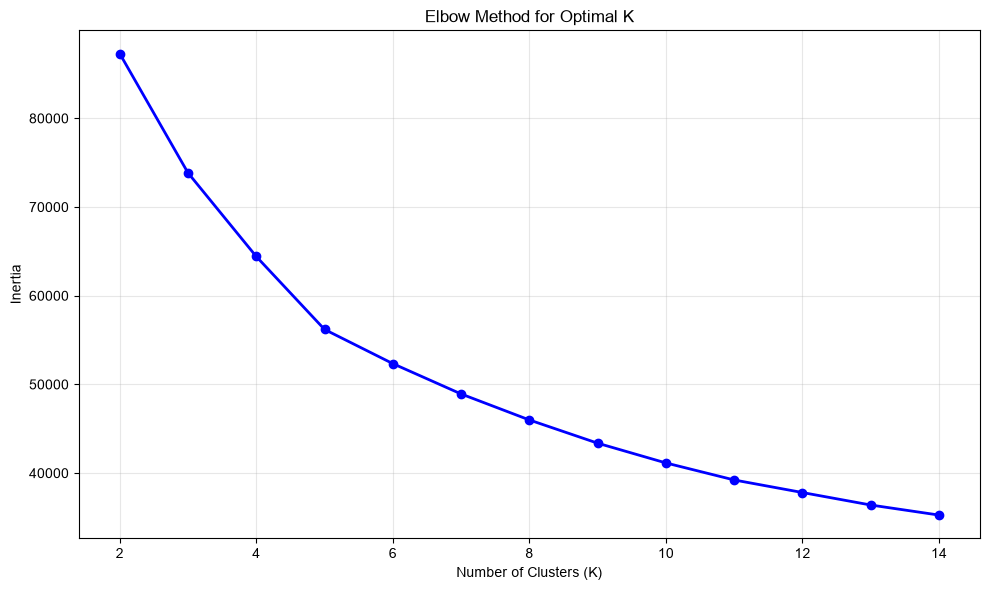

肘部图已保存到: extract-output/elbow_method.png

选择聚类数: 8

各聚类样本分布:
cluster
0    7496
1     958
2    2769
3    3323
4    4998
5     125
6    3273
7    1037
Name: count, dtype: int64


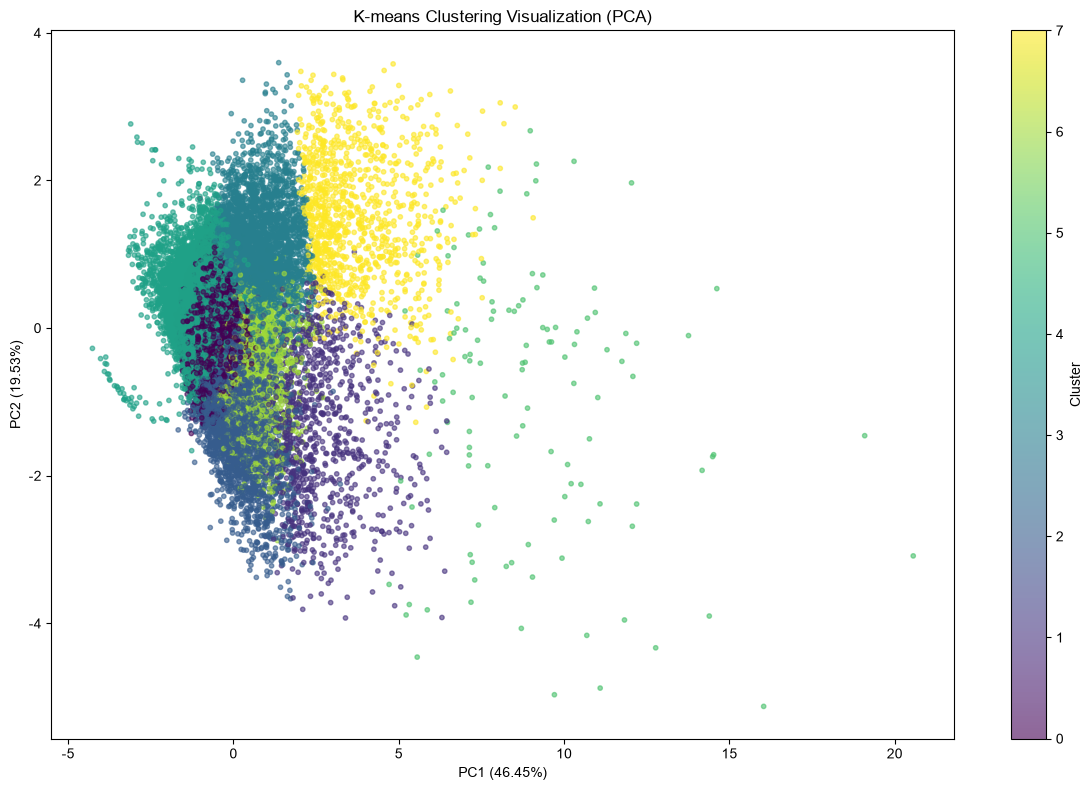

聚类可视化图已保存到: extract-output/cluster_visualization.png

各聚类股票数量:
cluster
0     94
1    100
2     96
3     99
4     73
5     54
6     76
7    100
Name: ts_code, dtype: int64


In [23]:
# ==================== 13. K-means聚类（基于量价特征） ====================

# 选择聚类特征
cluster_features = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'log_amount']
# 检查哪些特征存在
cluster_features = [f for f in cluster_features if f in df.columns]

print(f"聚类特征: {cluster_features}")

# 提取聚类数据
cluster_data = df[cluster_features].copy()

# 处理缺失值和无穷值
cluster_data = cluster_data.replace([np.inf, -np.inf], np.nan)
cluster_data = cluster_data.ffill().bfill().fillna(0)

# 标准化
cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_data)

# 确定聚类数量（使用肘部法则）
print("\n使用肘部法则确定最优聚类数...")
inertias = []
K_range = range(2, min(15, df['ts_code'].nunique() // 5 + 2))

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(cluster_data_scaled)
    inertias.append(kmeans_temp.inertia_)

# 绘制肘部图
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'elbow_method.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"肘部图已保存到: {output_dir}/elbow_method.png")

# 选择聚类数（根据肘部法则或固定值）
n_clusters = min(8, max(2, df['ts_code'].nunique() // 5))
print(f"\n选择聚类数: {n_clusters}")

# 执行K-means聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_data_scaled)

print(f"\n各聚类样本分布:")
cluster_dist = df['cluster'].value_counts().sort_index()
print(cluster_dist)

# 可视化聚类结果（使用PCA降维到2D）
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
cluster_data_pca = pca.fit_transform(cluster_data_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(cluster_data_pca[:, 0], cluster_data_pca[:, 1], 
                     c=df['cluster'], cmap='viridis', alpha=0.6, s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_title('K-means Clustering Visualization (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cluster_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"聚类可视化图已保存到: {output_dir}/cluster_visualization.png")

# 统计每个聚类的股票数量
cluster_stock_count = df.groupby('cluster')['ts_code'].nunique()
print(f"\n各聚类股票数量:")
print(cluster_stock_count)

In [24]:
# ==================== 14. 初始多因子选股回测 ====================
print("\n" + "="*80)
print("14. 初始多因子选股回测")
print("="*80)

def backtest_strategy(df, score_col, strategy_name, top_n=30, cluster_limit_ratio=0.3):
    """
    多因子选股回测
    """
    print(f"\n回测策略: {strategy_name}")
    
    # 初始化结果
    df[f'selected_{strategy_name}'] = 0
    daily_returns = []
    daily_dates = []
    selected_counts = []
    
    # 按月份分组进行调仓
    df['year_month'] = df['trade_date'].dt.to_period('M')
    
    print("开始选股回测...")
    for month, group in df.groupby('year_month'):
        if len(group) < top_n:
            continue
        
        # 限制每个聚类最多30%
        cluster_limit = max(1, int(cluster_limit_ratio * top_n))
        
        selected_stocks = []
        
        # 在每个聚类中选择得分最高的股票
        for cluster in group['cluster'].unique():
            cluster_group = group[group['cluster'] == cluster]
            if len(cluster_group) > 0:
                top_n_cluster = min(cluster_limit, len(cluster_group))
                top_stocks = cluster_group.nlargest(top_n_cluster, score_col)
                selected_stocks.extend(top_stocks.index.tolist())
        
        # 如果选股不足top_n，从剩余股票中补充
        if len(selected_stocks) < top_n:
            remaining = group[~group.index.isin(selected_stocks)]
            if len(remaining) > 0:
                additional = remaining.nlargest(top_n - len(selected_stocks), score_col)
                selected_stocks.extend(additional.index.tolist())
        
        # 标记选中的股票
        if len(selected_stocks) > 0:
            df.loc[selected_stocks, f'selected_{strategy_name}'] = 1
        
        selected_counts.append(len(selected_stocks))
    
    print(f"选股完成，平均选股数量: {np.mean(selected_counts):.1f}")
    
    # 计算每日组合收益
    print("计算组合收益...")
    daily_returns = []
    dates = []
    
    for date in df['trade_date'].unique():
        day_data = df[df['trade_date'] == date]
        selected = day_data[day_data[f'selected_{strategy_name}'] == 1]
        
        if len(selected) > 0:
            # 等权组合收益
            avg_return = selected['daily_return'].mean()
            if not np.isnan(avg_return):
                daily_returns.append(avg_return)
                dates.append(date)
    
    if len(daily_returns) == 0:
        print(f"{strategy_name} 没有交易记录")
        return None, None, None
    
    # 转换为时间序列
    returns_series = pd.Series(daily_returns, index=pd.to_datetime(dates))
    returns_series = returns_series.sort_index()
    
    # 计算累积收益
    cumulative_returns = (1 + returns_series).cumprod()
    
    # 计算绩效指标
    total_return = cumulative_returns.iloc[-1] - 1 if len(cumulative_returns) > 0 else 0
    annual_return = (1 + total_return) ** (252 / len(returns_series)) - 1 if len(returns_series) > 0 else 0
    volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 0 else 0
    sharpe_ratio = annual_return / volatility if volatility > 0 else 0
    
    # 最大回撤
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 胜率
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    print(f"\n{strategy_name} 绩效指标:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annual_return:.2%}")
    print(f"  年化波动率: {volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  胜率: {win_rate:.2%}")
    print(f"  交易天数: {len(returns_series)}")
    
    return returns_series, cumulative_returns, {
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_days': len(returns_series)
    }

# 回测加权策略（IR或IC）
print("\n" + "="*60)
print(f"回测{strategy_name}策略")
print("="*60)
returns_weighted, cum_weighted, metrics_weighted = backtest_strategy(
    df, 'composite_score_weighted', strategy_name, top_n=30, cluster_limit_ratio=0.3
)

# 回测等权策略
print("\n" + "="*60)
print("回测等权策略")
print("="*60)
returns_equal, cum_equal, metrics_equal = backtest_strategy(
    df, 'composite_score_equal', 'Equal_Weighted', top_n=30, cluster_limit_ratio=0.3
)



14. 初始多因子选股回测

回测IR_Weighted策略

回测策略: IR_Weighted
开始选股回测...
选股完成，平均选股数量: 68.4
计算组合收益...

IR_Weighted 绩效指标:
  总收益率: -11.27%
  年化收益率: -11.48%
  年化波动率: 41.92%
  夏普比率: -0.2738
  最大回撤: -42.72%
  胜率: 48.58%
  交易天数: 247

回测等权策略

回测策略: Equal_Weighted
开始选股回测...
选股完成，平均选股数量: 68.4
计算组合收益...

Equal_Weighted 绩效指标:
  总收益率: -37.75%
  年化收益率: -38.35%
  年化波动率: 44.15%
  夏普比率: -0.8686
  最大回撤: -50.17%
  胜率: 48.18%
  交易天数: 247


绩效指标已保存到: extract-output/initial_backtest_performance.csv

策略绩效对比:
         strategy  total_return  annual_return  sharpe_ratio  max_drawdown  win_rate
0     IR_Weighted     -0.112657      -0.114802     -0.273830     -0.427242  0.485830
1  Equal_Weighted     -0.377509      -0.383454     -0.868568     -0.501725  0.481781


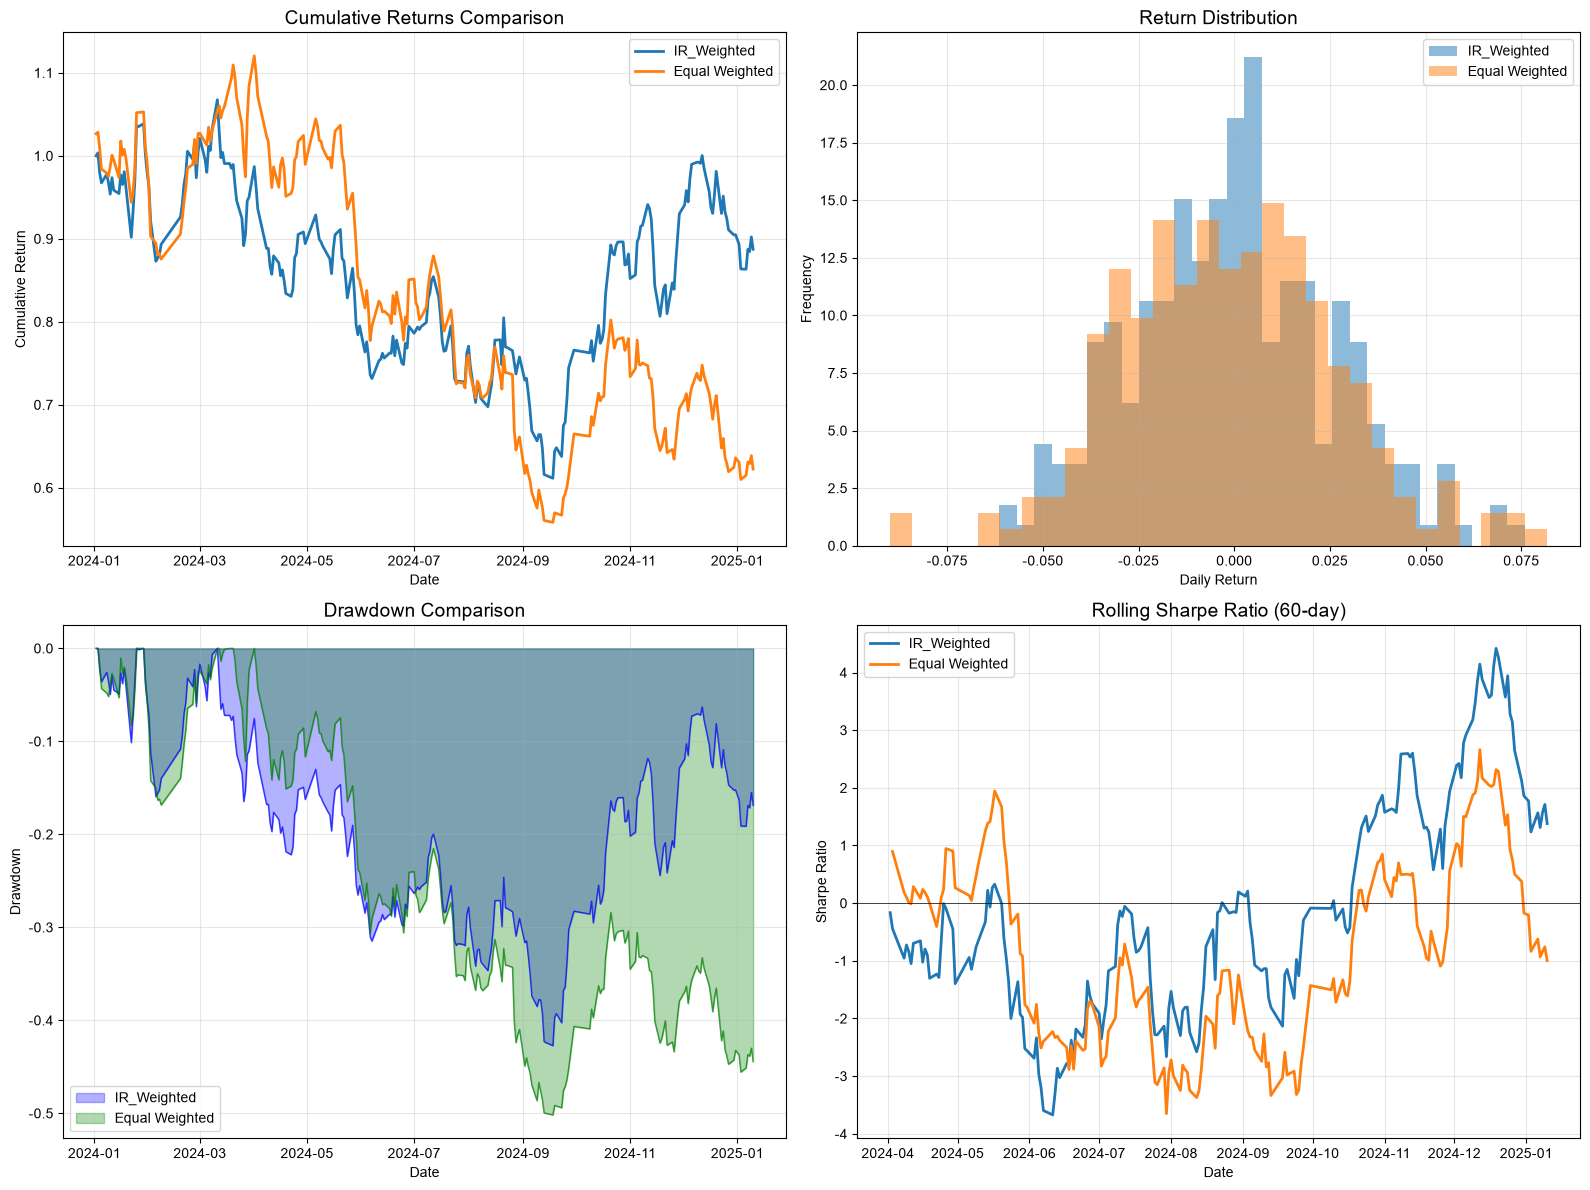

回测结果图已保存到: extract-output/initial_backtest_results.png


In [25]:
# 保存绩效指标
performance_results = []
if metrics_weighted:
    perf_weighted = metrics_weighted.copy()
    perf_weighted['strategy'] = strategy_name
    performance_results.append(perf_weighted)
if metrics_equal:
    perf_equal = metrics_equal.copy()
    perf_equal['strategy'] = 'Equal_Weighted'
    performance_results.append(perf_equal)

if performance_results:
    perf_df = pd.DataFrame(performance_results)
    perf_df.to_csv(os.path.join(output_dir, 'initial_backtest_performance.csv'), index=False)
    print(f"绩效指标已保存到: {output_dir}/initial_backtest_performance.csv")
    print("\n策略绩效对比:")
    print(perf_df[['strategy', 'total_return', 'annual_return', 'sharpe_ratio', 'max_drawdown', 'win_rate']].to_string())

# 绘制回测结果对比图
if returns_weighted is not None or returns_equal is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 累积收益对比
    ax1 = axes[0, 0]
    if cum_weighted is not None:
        ax1.plot(cum_weighted.index, cum_weighted, label=strategy_name, linewidth=2)
    if cum_equal is not None:
        ax1.plot(cum_equal.index, cum_equal, label='Equal Weighted', linewidth=2)
    ax1.set_title('Cumulative Returns Comparison', fontsize=14)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 收益分布
    ax2 = axes[0, 1]
    if returns_weighted is not None:
        ax2.hist(returns_weighted.dropna(), bins=30, alpha=0.5, label=strategy_name, density=True)
    if returns_equal is not None:
        ax2.hist(returns_equal.dropna(), bins=30, alpha=0.5, label='Equal Weighted', density=True)
    ax2.set_title('Return Distribution', fontsize=14)
    ax2.set_xlabel('Daily Return')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 回撤对比
    ax3 = axes[1, 0]
    if cum_weighted is not None:
        rolling_max_weighted = cum_weighted.expanding().max()
        drawdown_weighted = (cum_weighted - rolling_max_weighted) / rolling_max_weighted
        ax3.fill_between(drawdown_weighted.index, drawdown_weighted, 0, alpha=0.3, label=strategy_name, color='blue')
        ax3.plot(drawdown_weighted.index, drawdown_weighted, linewidth=1, color='blue', alpha=0.7)
    
    if cum_equal is not None:
        rolling_max_equal = cum_equal.expanding().max()
        drawdown_equal = (cum_equal - rolling_max_equal) / rolling_max_equal
        ax3.fill_between(drawdown_equal.index, drawdown_equal, 0, alpha=0.3, label='Equal Weighted', color='green')
        ax3.plot(drawdown_equal.index, drawdown_equal, linewidth=1, color='green', alpha=0.7)
    
    ax3.set_title('Drawdown Comparison', fontsize=14)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Drawdown')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 滚动夏普比率
    ax4 = axes[1, 1]
    if returns_weighted is not None:
        rolling_sharpe_weighted = returns_weighted.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        ax4.plot(rolling_sharpe_weighted.index, rolling_sharpe_weighted, label=strategy_name, linewidth=2)
    
    if returns_equal is not None:
        rolling_sharpe_equal = returns_equal.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        ax4.plot(rolling_sharpe_equal.index, rolling_sharpe_equal, label='Equal Weighted', linewidth=2)
    
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax4.set_title('Rolling Sharpe Ratio (60-day)', fontsize=14)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'initial_backtest_results.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"回测结果图已保存到: {output_dir}/initial_backtest_results.png")


17.1 获取因子收益序列（Brinson归因）...
用于Brinson归因的因子数量: 20
因子收益矩阵形状: (249, 20)

因子收益统计:
       auto_kurtosis_20  hist_vol_60  auto_volatility_20  hist_vol_20  \
count        249.000000   249.000000          249.000000   249.000000   
mean          -0.000161    -0.003900           -0.003865    -0.004757   
std            0.001249     0.057030            0.023640     0.053138   
min           -0.007760    -0.170948           -0.121210    -0.199567   
25%           -0.000815    -0.041948           -0.015454    -0.039165   
50%           -0.000278    -0.002364           -0.001668    -0.002577   
75%            0.000447     0.033937            0.009591     0.032594   
max            0.004061     0.167156            0.107953     0.198299   

       auto_volatility_60  auto_std_60_1  auto_amount_ma_30  \
count          249.000000     249.000000       2.490000e+02   
mean            -0.001584       0.000091      -9.968568e-11   
std              0.021524       0.001920       9.008839e-09   
min        

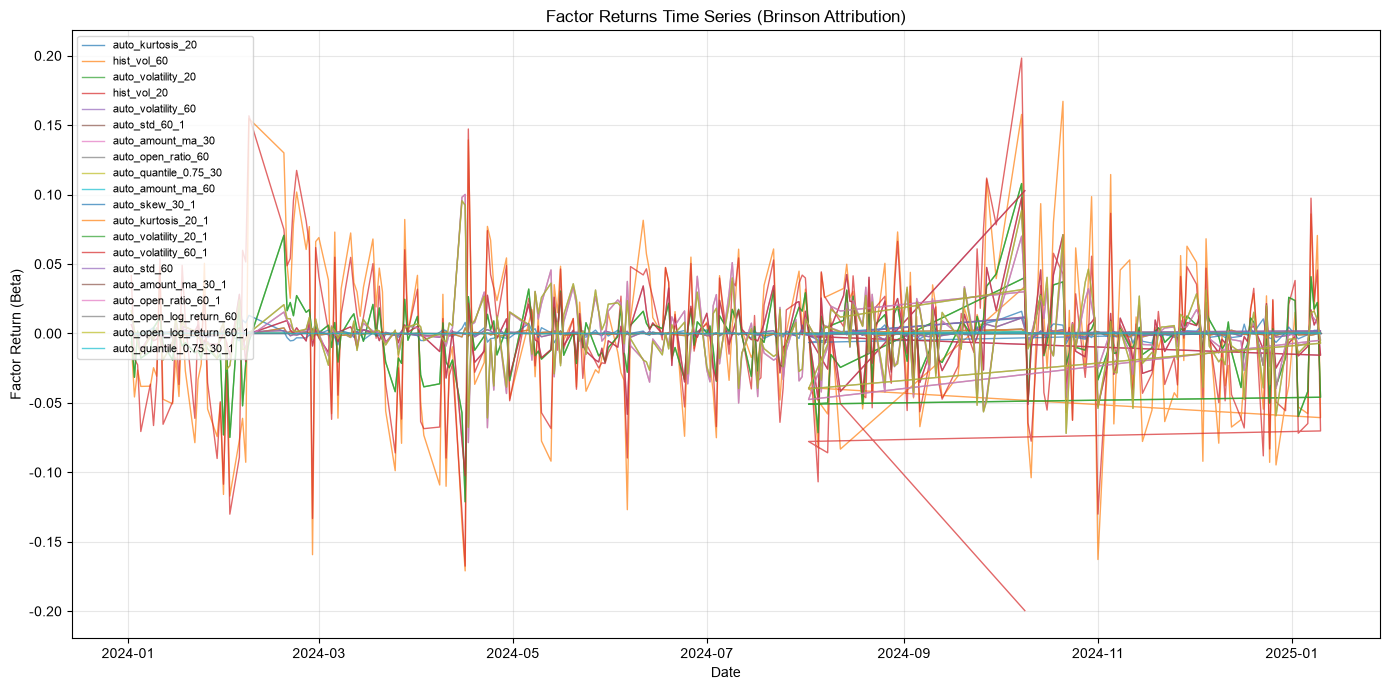

因子收益序列图已保存到: extract-output/factor_returns_brinson_series.png


In [27]:
# 17.1 获取因子收益序列（Brinson归因）
print("\n17.1 获取因子收益序列（Brinson归因）...")

def calculate_factor_returns_brinson(df, factor_cols, returns_col='daily_return'):
    """
    使用Brinson归因方法计算因子收益序列
    通过每日截面回归，获取每个因子的边际贡献（系数）
    """
    factor_returns = {}
    
    # 获取最终因子的原始列名（用于回归）
    factor_cols_original = [f.replace('_processed', '') for f in factor_cols if f.replace('_processed', '') in df.columns]
    
    if len(factor_cols_original) == 0:
        print("警告: 没有可用的原始因子列，使用预处理后的因子列")
        factor_cols_original = [f for f in factor_cols if f in df.columns]
    
    print(f"用于Brinson归因的因子数量: {len(factor_cols_original)}")
    
    for col in factor_cols_original:
        daily_betas = []
        daily_dates = []
        
        for date in df['trade_date'].unique():
            day_data = df[df['trade_date'] == date].dropna(subset=[col, returns_col])
            if len(day_data) < 10:
                continue
            
            try:
                X = day_data[col].values.reshape(-1, 1)
                y = day_data[returns_col].values
                X = np.column_stack([np.ones(len(X)), X])
                
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                daily_betas.append(beta[1])  # 因子系数
                daily_dates.append(date)
            except:
                continue
        
        if len(daily_betas) > 0:
            factor_returns[col] = pd.Series(daily_betas, index=pd.to_datetime(daily_dates))
    
    # 转换为DataFrame
    if len(factor_returns) > 0:
        factor_returns_df = pd.DataFrame(factor_returns)
        factor_returns_df = factor_returns_df.dropna()
        print(f"因子收益矩阵形状: {factor_returns_df.shape}")
        print("\n因子收益统计:")
        print(factor_returns_df.describe())
        
        # 保存因子收益序列
        factor_returns_df.to_csv(os.path.join(output_dir, 'factor_returns_brinson.csv'))
        print(f"因子收益序列已保存到: {output_dir}/factor_returns_brinson.csv")
        
        # 绘制因子收益序列
        fig, ax = plt.subplots(figsize=(14, 7))
        for col in factor_returns_df.columns:
            ax.plot(factor_returns_df.index, factor_returns_df[col], label=col[:30], alpha=0.7, linewidth=1)
        ax.set_xlabel('Date')
        ax.set_ylabel('Factor Return (Beta)')
        ax.set_title('Factor Returns Time Series (Brinson Attribution)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'factor_returns_brinson_series.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"因子收益序列图已保存到: {output_dir}/factor_returns_brinson_series.png")
        
        return factor_returns_df
    else:
        print("警告: 无法计算因子收益序列")
        return None


# 执行Brinson归因
factor_returns_df = calculate_factor_returns_brinson(df, final_factors)


17.2 检查优化问题的凸性...
协方差矩阵是否正定: False
优化问题是否为凸: False
协方差矩阵已保存到: extract-output/factor_covariance_matrix.csv

17.3 定义优化目标函数...

17.4 非凸优化：使用遗传算法和模拟退火...

17.4.1 遗传算法优化...

17.4.2 模拟退火优化...
运行遗传算法...
遗传算法最优夏普比率: 0.0595
遗传算法最优权重:
  auto_kurtosis_20: 0.0000
  hist_vol_60: 0.0000
  auto_volatility_20: 0.0000
  hist_vol_20: 0.0000
  auto_volatility_60: 0.0000
  auto_std_60_1: 0.0001
  auto_amount_ma_30: 0.0000
  auto_open_ratio_60: 0.0000
  auto_quantile_0.75_30: 0.5085
  auto_amount_ma_60: 0.0000
  auto_skew_30_1: 0.0000
  auto_kurtosis_20_1: 0.0000
  auto_volatility_20_1: 0.0000
  auto_volatility_60_1: 0.0000
  auto_std_60: 0.0001
  auto_amount_ma_30_1: 0.0019
  auto_open_ratio_60_1: 0.0000
  auto_open_log_return_60: 0.0000
  auto_open_log_return_60_1: 0.0000
  auto_quantile_0.75_30_1: 0.4894

运行模拟退火...
模拟退火最优夏普比率: -0.0697
模拟退火最优权重:
  auto_kurtosis_20: 0.0000
  hist_vol_60: 0.4042
  auto_volatility_20: 0.0000
  hist_vol_20: 0.0000
  auto_volatility_60: 0.0387
  auto_std_60_1: 0.0000
  auto_

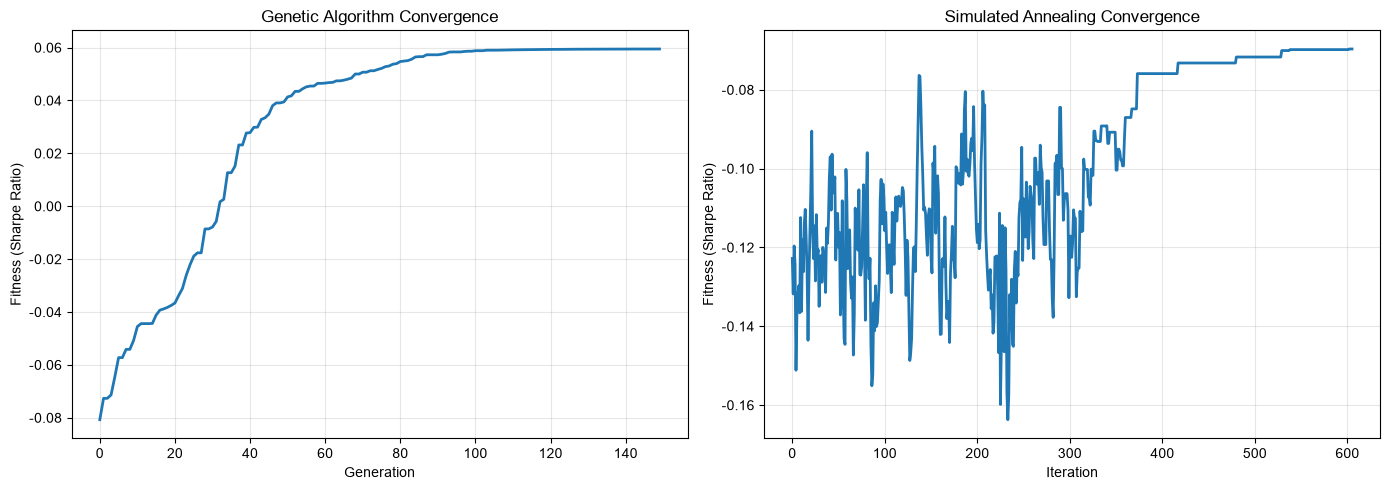

优化收敛图已保存到: extract-output/optimization_convergence.png

17.5 保存优化结果...
优化权重已保存到: extract-output/optimal_weights.csv

17.6 使用优化权重计算综合因子得分...
优化后综合因子得分统计:
count    2.397900e+04
mean    -2.844660e-17
std      9.982589e-01
min     -7.775803e-01
25%     -5.069333e-01
50%     -2.982846e-01
75%      1.572029e-01
max      9.306070e+00
Name: composite_score_optimized, dtype: float64


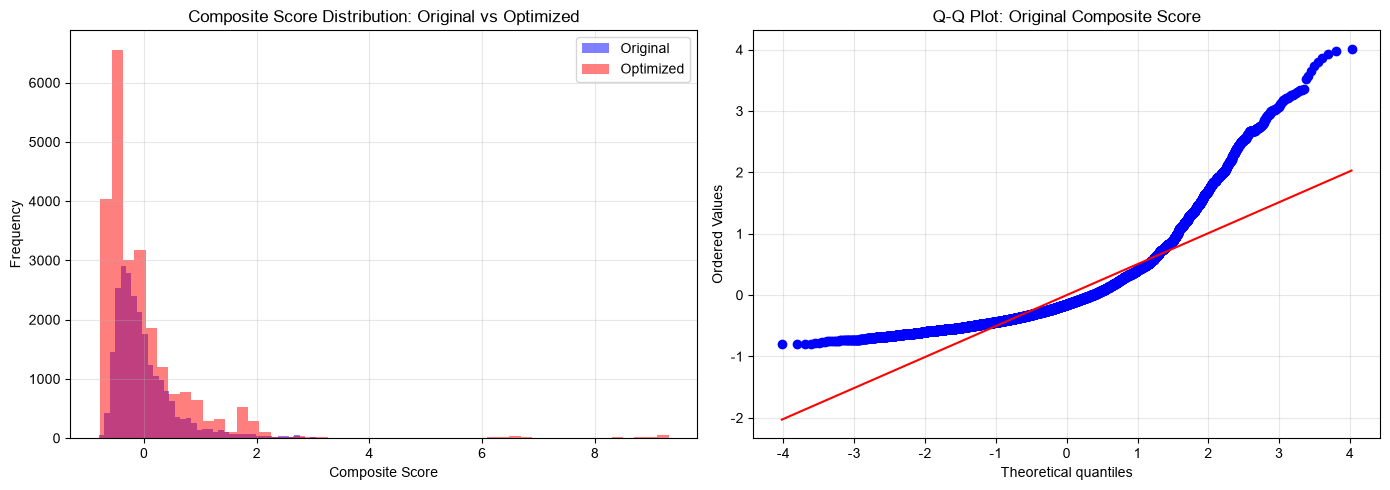

综合得分对比图已保存到: extract-output/composite_score_optimized_comparison.png

17.7 优化策略回测...

回测策略: Optimized
开始选股回测...
选股完成，平均选股数量: 68.4
计算组合收益...

Optimized 绩效指标:
  总收益率: 34.77%
  年化收益率: 36.44%
  年化波动率: 41.97%
  夏普比率: 0.8682
  最大回撤: -26.94%
  胜率: 50.41%
  交易天数: 242

17.8 优化前后回测结果对比

所有策略绩效对比:
                      strategy  total_return  annual_return  sharpe_ratio  max_drawdown  win_rate
0                  IR_Weighted     -0.112657      -0.114802     -0.273830     -0.427242  0.485830
1               Equal_Weighted     -0.377509      -0.383454     -0.868568     -0.501725  0.481781
2  Optimized_Genetic_Algorithm      0.347688       0.364408      0.868167     -0.269434  0.504132


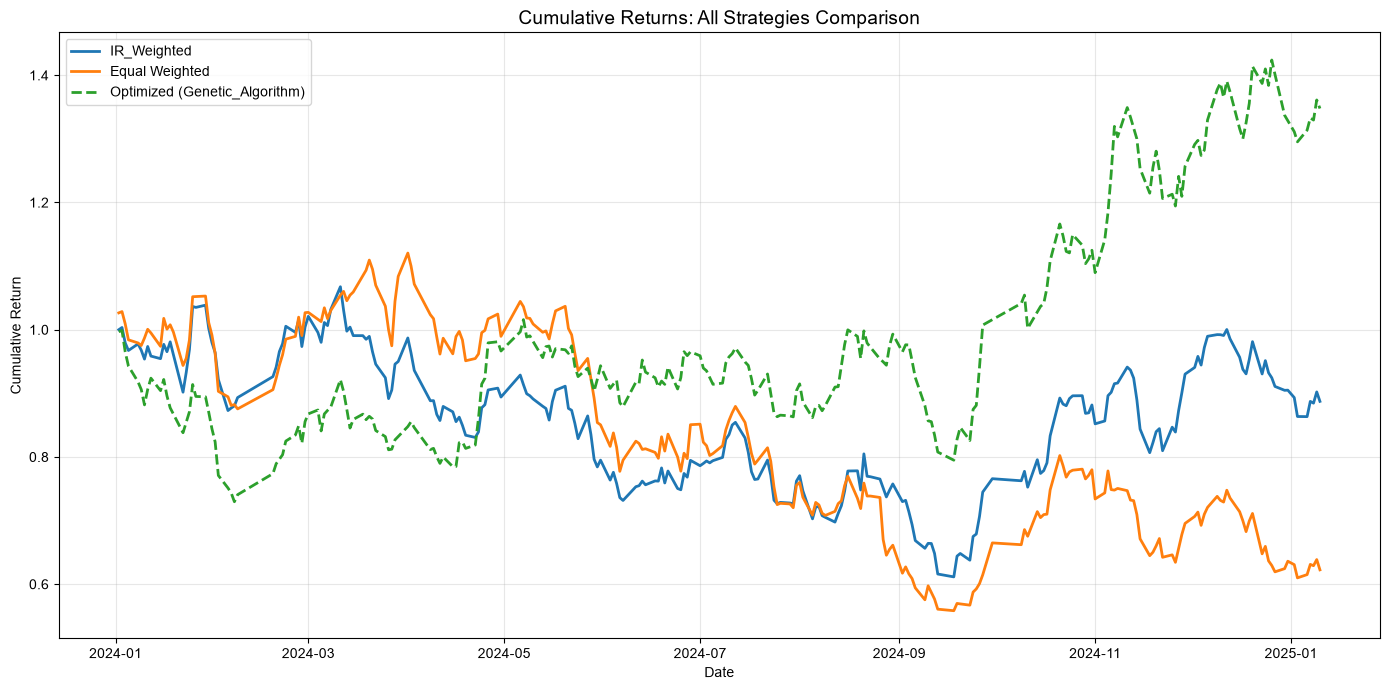

所有策略对比图已保存到: extract-output/all_strategies_comparison.png


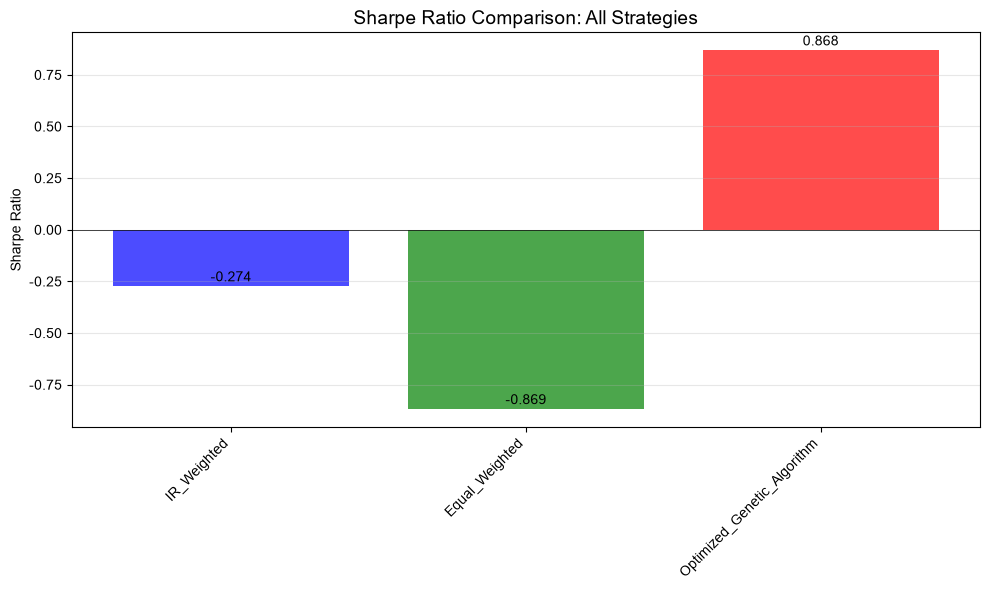

夏普比率对比图已保存到: extract-output/sharpe_ratio_comparison.png

17.9 因子权重优化最终总结


优化信息:
- 优化方法: Genetic_Algorithm
- 优化后夏普比率: 0.0595
- 优化问题凸性: 非凸

策略表现对比:
IR_Weighted策略:
- 年化收益率: -11.48%
- 夏普比率: -0.2738
- 最大回撤: -42.72%

优化策略 (Genetic_Algorithm):
- 年化收益率: 36.44%
- 夏普比率: 0.8682
- 最大回撤: -26.94%

等权策略:
- 年化收益率: -38.35%
- 夏普比率: -0.8686
- 最大回撤: -50.17%


性能提升:
- 夏普比率提升: 1.1420

输出文件:
- extract-output/factor_returns_brinson.csv - 因子收益序列
- extract-output/factor_covariance_matrix.csv - 协方差矩阵
- extract-output/optimal_weights.csv - 优化权重
- extract-output/optimization_convergence.png - 优化收敛图
- extract-output/composite_score_optimized_comparison.png - 综合得分对比
- extract-output/all_strategies_performance.csv - 所有策略绩效
- extract-output/all_strategies_comparison.png - 所有策略收益对比
- extract-output/sharpe_ratio_comparison.png - 夏普比率对比


✅ 因子权重优化和对比回测完成！


In [28]:
if factor_returns_df is not None:
    # 17.2 检查优化问题的凸性
    print("\n17.2 检查优化问题的凸性...")
    
    # 计算协方差矩阵
    cov_matrix = factor_returns_df.cov()
    
    # 检查协方差矩阵是否正定
    from scipy.linalg import eigh
    eigenvalues = eigh(cov_matrix)[0]
    is_positive_definite = np.all(eigenvalues > 1e-6)
    print(f"协方差矩阵是否正定: {is_positive_definite}")
    
    # 检查是否为凸函数（正定协方差矩阵 + 线性约束）
    is_convex = is_positive_definite
    print(f"优化问题是否为凸: {is_convex}")
    
    # 保存协方差矩阵
    cov_matrix.to_csv(os.path.join(output_dir, 'factor_covariance_matrix.csv'))
    print(f"协方差矩阵已保存到: {output_dir}/factor_covariance_matrix.csv")
    
    # 17.3 定义目标函数
    print("\n17.3 定义优化目标函数...")
    
    def negative_sharpe(weights, returns_matrix):
        """负夏普比率（用于最小化）"""
        weights = np.array(weights)
        # 确保权重归一化
        weights = weights / (weights.sum() + 1e-6)
        portfolio_return = np.sum(returns_matrix.mean() * weights)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns_matrix.cov(), weights)))
        sharpe = portfolio_return / (portfolio_volatility + 1e-6)
        return -sharpe
    
    def sharpe_ratio(weights, returns_matrix):
        """夏普比率（用于最大化）"""
        weights = np.array(weights)
        weights = weights / (weights.sum() + 1e-6)
        portfolio_return = np.sum(returns_matrix.mean() * weights)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns_matrix.cov(), weights)))
        return portfolio_return / (portfolio_volatility + 1e-6)
    
    # 17.4 凸优化（如果问题为凸）
    if is_convex:
        print("\n17.4 凸优化求解...")
        from scipy.optimize import minimize
        
        n_factors = factor_returns_df.shape[1]
        
        # 约束条件：权重之和为1，权重非负
        constraints = [
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
        ]
        bounds = [(0, 1) for _ in range(n_factors)]
        
        # 初始解：等权
        initial_weights = np.ones(n_factors) / n_factors
        
        # 优化
        result = minimize(
            negative_sharpe,
            initial_weights,
            args=(factor_returns_df,),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        
        convex_weights = result.x / result.x.sum()
        convex_sharpe = -result.fun
        
        print(f"凸优化完成，最优夏普比率: {convex_sharpe:.4f}")
        print("\n凸优化最优权重:")
        for i, col in enumerate(factor_returns_df.columns):
            print(f"  {col}: {convex_weights[i]:.4f}")
        
        optimal_weights = convex_weights
        optimal_sharpe = convex_sharpe
        optimization_method = 'Convex_Optimization'
        
    else:
        print("\n17.4 非凸优化：使用遗传算法和模拟退火...")
        
        # 17.4.1 遗传算法
        print("\n17.4.1 遗传算法优化...")
        
        def genetic_algorithm(returns_matrix, n_population=100, n_generations=150, mutation_rate=0.1):
            """遗传算法优化权重"""
            n_factors = returns_matrix.shape[1]
            
            # 初始化种群
            population = np.random.dirichlet(np.ones(n_factors), size=n_population)
            fitness_history = []
            best_fitness_history = []
            
            for generation in range(n_generations):
                # 计算适应度
                fitness = np.array([-negative_sharpe(ind, returns_matrix) for ind in population])
                
                # 记录最优
                best_idx = np.argmax(fitness)
                best_weights = population[best_idx].copy()
                best_fitness = fitness[best_idx]
                fitness_history.append(best_fitness)
                
                # 锦标赛选择
                selected = []
                for _ in range(n_population):
                    idx1 = np.random.randint(n_population)
                    idx2 = np.random.randint(n_population)
                    if fitness[idx1] > fitness[idx2]:
                        selected.append(population[idx1].copy())
                    else:
                        selected.append(population[idx2].copy())
                selected = np.array(selected)
                
                # 交叉
                offspring = []
                for i in range(0, n_population, 2):
                    if i+1 < n_population:
                        parent1 = selected[i]
                        parent2 = selected[i+1]
                        mask = np.random.random(n_factors) > 0.5
                        child1 = parent1 * mask + parent2 * (1 - mask)
                        child2 = parent2 * mask + parent1 * (1 - mask)
                        child1 = child1 / (child1.sum() + 1e-6)
                        child2 = child2 / (child2.sum() + 1e-6)
                        offspring.extend([child1, child2])
                
                # 变异
                for i in range(len(offspring)):
                    if np.random.random() < mutation_rate:
                        idx = np.random.randint(n_factors)
                        offspring[i][idx] = np.random.random()
                        offspring[i] = offspring[i] / (offspring[i].sum() + 1e-6)
                
                # 精英保留
                n_elite = max(1, int(0.1 * n_population))
                elite_idx = np.argsort(fitness)[-n_elite:]
                elite = population[elite_idx]
                
                # 新种群
                population = np.vstack([elite, np.array(offspring[:n_population - n_elite])])
            
            # 返回最优权重
            final_fitness = np.array([-negative_sharpe(ind, returns_matrix) for ind in population])
            best_idx = np.argmax(final_fitness)
            return population[best_idx], fitness_history
        
        # 17.4.2 模拟退火
        print("\n17.4.2 模拟退火优化...")
        
        def simulated_annealing(returns_matrix, n_iterations=8000, initial_temp=100, cooling_rate=0.97):
            """模拟退火算法优化权重"""
            n_factors = returns_matrix.shape[1]
            
            # 初始解（等权）
            current_weights = np.ones(n_factors) / n_factors
            current_sharpe = -negative_sharpe(current_weights, returns_matrix)
            best_weights = current_weights.copy()
            best_sharpe = current_sharpe
            sharpe_history = [current_sharpe]
            
            temp = initial_temp
            
            for iteration in range(n_iterations):
                # 生成邻域解
                new_weights = current_weights + np.random.normal(0, 0.05, n_factors)
                new_weights = np.maximum(new_weights, 0)
                new_weights = new_weights / (new_weights.sum() + 1e-6)
                
                new_sharpe = -negative_sharpe(new_weights, returns_matrix)
                delta = new_sharpe - current_sharpe
                
                # 接受准则
                if delta > 0 or np.random.random() < np.exp(delta / (temp + 1e-6)):
                    current_weights = new_weights
                    current_sharpe = new_sharpe
                    
                    if new_sharpe > best_sharpe:
                        best_weights = new_weights.copy()
                        best_sharpe = new_sharpe
                
                sharpe_history.append(current_sharpe)
                
                # 降温
                temp *= cooling_rate
                
                if temp < 1e-6:
                    break
            
            return best_weights, sharpe_history
        
        # 运行遗传算法
        print("运行遗传算法...")
        ga_weights, ga_fitness = genetic_algorithm(factor_returns_df)
        ga_sharpe = -negative_sharpe(ga_weights, factor_returns_df)
        
        print(f"遗传算法最优夏普比率: {ga_sharpe:.4f}")
        print("遗传算法最优权重:")
        for i, col in enumerate(factor_returns_df.columns):
            print(f"  {col}: {ga_weights[i]:.4f}")
        
        # 运行模拟退火
        print("\n运行模拟退火...")
        sa_weights, sa_fitness = simulated_annealing(factor_returns_df)
        sa_sharpe = -negative_sharpe(sa_weights, factor_returns_df)
        
        print(f"模拟退火最优夏普比率: {sa_sharpe:.4f}")
        print("模拟退火最优权重:")
        for i, col in enumerate(factor_returns_df.columns):
            print(f"  {col}: {sa_weights[i]:.4f}")
        
        # 选择较优结果
        if ga_sharpe > sa_sharpe:
            optimal_weights = ga_weights
            optimal_sharpe = ga_sharpe
            optimization_method = 'Genetic_Algorithm'
            print(f"\n选择遗传算法结果 (夏普比率更高: {ga_sharpe:.4f} vs {sa_sharpe:.4f})")
        else:
            optimal_weights = sa_weights
            optimal_sharpe = sa_sharpe
            optimization_method = 'Simulated_Annealing'
            print(f"\n选择模拟退火结果 (夏普比率更高: {sa_sharpe:.4f} vs {ga_sharpe:.4f})")
        
        # 绘制优化收敛图
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(ga_fitness, linewidth=2)
        axes[0].set_xlabel('Generation')
        axes[0].set_ylabel('Fitness (Sharpe Ratio)')
        axes[0].set_title('Genetic Algorithm Convergence')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(sa_fitness, linewidth=2)
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Fitness (Sharpe Ratio)')
        axes[1].set_title('Simulated Annealing Convergence')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'optimization_convergence.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"优化收敛图已保存到: {output_dir}/optimization_convergence.png")
    
    # 17.5 保存优化结果
    print("\n17.5 保存优化结果...")
    
    # 创建权重字典
    optimal_weight_dict = dict(zip(factor_returns_df.columns, optimal_weights))
    
    # 保存优化结果
    optimization_results = pd.DataFrame({
        'factor': factor_returns_df.columns,
        'optimal_weight': optimal_weights,
        'method': optimization_method
    })
    optimization_results.to_csv(os.path.join(output_dir, 'optimal_weights.csv'), index=False)
    print(f"优化权重已保存到: {output_dir}/optimal_weights.csv")
    
    # 17.6 使用优化权重计算综合因子得分
    print("\n17.6 使用优化权重计算综合因子得分...")
    
    # 获取因子数据（原始值）
    factor_cols_original = [col for col in factor_returns_df.columns if col in df.columns]
    
    if len(factor_cols_original) > 0:
        factor_data_opt = df[factor_cols_original].copy()
        
        # 处理缺失值
        factor_data_opt = factor_data_opt.replace([np.inf, -np.inf], np.nan)
        factor_data_opt = factor_data_opt.ffill().bfill().fillna(0)
        
        # 计算优化后的综合得分
        df['composite_score_optimized'] = calculate_composite_score(factor_data_opt, optimal_weight_dict)
        
        print("优化后综合因子得分统计:")
        print(df['composite_score_optimized'].describe())
        
        # 绘制优化前后综合得分对比
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].hist(df['composite_score_weighted'].dropna(), bins=50, alpha=0.5, label='Original', color='blue')
        axes[0].hist(df['composite_score_optimized'].dropna(), bins=50, alpha=0.5, label='Optimized', color='red')
        axes[0].set_xlabel('Composite Score')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Composite Score Distribution: Original vs Optimized')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # QQ图对比
        from scipy import stats as stats_qq
        stats_qq.probplot(df['composite_score_weighted'].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot: Original Composite Score')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'composite_score_optimized_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"综合得分对比图已保存到: {output_dir}/composite_score_optimized_comparison.png")
        
        # 17.7 优化策略回测
        print("\n17.7 优化策略回测...")
        
        # 使用优化权重选股回测
        returns_opt, cum_opt, metrics_opt = backtest_strategy(
            df, 'composite_score_optimized', 'Optimized', top_n=30, cluster_limit_ratio=0.3
        )
        
        # 17.8 优化前后回测结果对比
        print("\n" + "="*80)
        print("17.8 优化前后回测结果对比")
        print("="*80)
        
        # 收集所有策略绩效
        all_performance = []
        
        if metrics_weighted:
            perf_orig = metrics_weighted.copy()
            perf_orig['strategy'] = strategy_name
            all_performance.append(perf_orig)
        
        if metrics_equal:
            perf_equal = metrics_equal.copy()
            perf_equal['strategy'] = 'Equal_Weighted'
            all_performance.append(perf_equal)
        
        if metrics_opt:
            perf_opt = metrics_opt.copy()
            perf_opt['strategy'] = f'Optimized_{optimization_method}'
            all_performance.append(perf_opt)
        
        if all_performance:
            all_perf_df = pd.DataFrame(all_performance)
            all_perf_df.to_csv(os.path.join(output_dir, 'all_strategies_performance.csv'), index=False)
            print("\n所有策略绩效对比:")
            print(all_perf_df[['strategy', 'total_return', 'annual_return', 'sharpe_ratio', 'max_drawdown', 'win_rate']].to_string())
        
        # 绘制所有策略累积收益对比
        fig, ax = plt.subplots(figsize=(14, 7))
        
        if cum_weighted is not None:
            ax.plot(cum_weighted.index, cum_weighted, label=strategy_name, linewidth=2)
        if cum_equal is not None:
            ax.plot(cum_equal.index, cum_equal, label='Equal Weighted', linewidth=2)
        if cum_opt is not None:
            ax.plot(cum_opt.index, cum_opt, label=f'Optimized ({optimization_method})', linewidth=2, linestyle='--')
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        ax.set_title('Cumulative Returns: All Strategies Comparison', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'all_strategies_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"所有策略对比图已保存到: {output_dir}/all_strategies_comparison.png")
        
        # 绘制夏普比率对比柱状图
        fig, ax = plt.subplots(figsize=(10, 6))
        
        strategies = all_perf_df['strategy'].tolist()
        sharpe_values = all_perf_df['sharpe_ratio'].values
        
        bars = ax.bar(range(len(strategies)), sharpe_values, alpha=0.7, 
                     color=['blue', 'green', 'red'])
        ax.set_xticks(range(len(strategies)))
        ax.set_xticklabels(strategies, rotation=45, ha='right')
        ax.set_ylabel('Sharpe Ratio')
        ax.set_title('Sharpe Ratio Comparison: All Strategies', fontsize=14)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 添加数值标签
        for bar, value in zip(bars, sharpe_values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sharpe_ratio_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"夏普比率对比图已保存到: {output_dir}/sharpe_ratio_comparison.png")
        
        # 17.9 最终总结
        print("\n" + "="*80)
        print("17.9 因子权重优化最终总结")
        print("="*80)
        
        opt_annual = f"{metrics_opt['annual_return']:.2%}" if metrics_opt and metrics_opt['annual_return'] is not None else 'N/A'
        opt_sharpe = f"{metrics_opt['sharpe_ratio']:.4f}" if metrics_opt and metrics_opt['sharpe_ratio'] is not None else 'N/A'
        opt_drawdown = f"{metrics_opt['max_drawdown']:.2%}" if metrics_opt and metrics_opt['max_drawdown'] is not None else 'N/A'
        
        weighted_annual_val = metrics_weighted['annual_return'] if metrics_weighted and metrics_weighted['annual_return'] is not None else 0
        weighted_sharpe_val = metrics_weighted['sharpe_ratio'] if metrics_weighted and metrics_weighted['sharpe_ratio'] is not None else 0
        weighted_drawdown_val = metrics_weighted['max_drawdown'] if metrics_weighted and metrics_weighted['max_drawdown'] is not None else 0
        
        equal_annual_val = metrics_equal['annual_return'] if metrics_equal and metrics_equal['annual_return'] is not None else 0
        equal_sharpe_val = metrics_equal['sharpe_ratio'] if metrics_equal and metrics_equal['sharpe_ratio'] is not None else 0
        equal_drawdown_val = metrics_equal['max_drawdown'] if metrics_equal and metrics_equal['max_drawdown'] is not None else 0
        
        opt_annual_val = metrics_opt['annual_return'] if metrics_opt and metrics_opt['annual_return'] is not None else 0
        opt_sharpe_val = metrics_opt['sharpe_ratio'] if metrics_opt and metrics_opt['sharpe_ratio'] is not None else 0
        opt_drawdown_val = metrics_opt['max_drawdown'] if metrics_opt and metrics_opt['max_drawdown'] is not None else 0
        
        # 计算夏普比率提升
        sharpe_improvement = opt_sharpe_val - weighted_sharpe_val if opt_sharpe_val != 0 and weighted_sharpe_val != 0 else 0
        
        print(f"""

优化信息:
- 优化方法: {optimization_method}
- 优化后夏普比率: {optimal_sharpe:.4f}
- 优化问题凸性: {'凸' if is_convex else '非凸'}

策略表现对比:
{strategy_name}策略:
- 年化收益率: {weighted_annual_val:.2%}
- 夏普比率: {weighted_sharpe_val:.4f}
- 最大回撤: {weighted_drawdown_val:.2%}

优化策略 ({optimization_method}):
- 年化收益率: {opt_annual}
- 夏普比率: {opt_sharpe}
- 最大回撤: {opt_drawdown}

等权策略:
- 年化收益率: {equal_annual_val:.2%}
- 夏普比率: {equal_sharpe_val:.4f}
- 最大回撤: {equal_drawdown_val:.2%}


性能提升:
- 夏普比率提升: {sharpe_improvement:.4f}

输出文件:
- {output_dir}/factor_returns_brinson.csv - 因子收益序列
- {output_dir}/factor_covariance_matrix.csv - 协方差矩阵
- {output_dir}/optimal_weights.csv - 优化权重
- {output_dir}/optimization_convergence.png - 优化收敛图
- {output_dir}/composite_score_optimized_comparison.png - 综合得分对比
- {output_dir}/all_strategies_performance.csv - 所有策略绩效
- {output_dir}/all_strategies_comparison.png - 所有策略收益对比
- {output_dir}/sharpe_ratio_comparison.png - 夏普比率对比
================================================================
""")
        
    else:
        print("无法获取因子数据用于优化权重")
else:
    print("无法计算因子收益序列，跳过权重优化")

print("\n" + "="*80)
print("✅ 因子权重优化和对比回测完成！")
print("="*80)